<h1 align="center" id="top"><u>RL project</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ | Fanny BADOULES | Ghiles KEMICHE</u></h3>

# Table of Contents
***
1. [Import](#import)
2. [Testing](#testing)

Remarque : notre extension qui consiste à l'étude d'un double DQN et de différente configuation est directement comparée dans ce notebook avec nos modèles de la Core task.

## Import
***

In [35]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from rl_project.benchmark.benchmark import HighwayBenchmark
from rl_project.benchmark.typing import BenchmarkConfig
from rl_project.models.core.typing import ModelType
from rl_project.models.factory import load_model
from scripts.envs.factory import get_env_config
from scripts.envs.typing import EnvType
from scripts.utils.cache import CacheManager
from scripts.utils.display import display_episode


In [36]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


def build_dataframe_name(csv_path: Path, data_dir: Path) -> str:
    relative_parts = csv_path.relative_to(data_dir).with_suffix("").parts
    sanitized_parts = [part.replace("-", "_") for part in relative_parts]
    return "_".join(sanitized_parts) + "_df"


def resolve_model_path(
    project_root: Path,
    model_type: ModelType,
    env_type: EnvType,
    train_seed: int,
    checkpoint: int | None = None,
) -> Path:
    model_dir = (
        project_root
        / "data"
        / "training"
        / model_type.value
        / env_type.value
        / f"seed_{train_seed}"
    )

    if checkpoint is None:
        matches = sorted(
            model_dir.glob(f"model_{model_type.value}_{env_type.value}_seed_{train_seed}_*.pt")
        )
        if not matches:
            matches = sorted(model_dir.glob("model*.pt"))
    else:
        matches = sorted(model_dir.glob(f"checkpoint*ep_{checkpoint}.pt"))
        if not matches:
            matches = sorted(model_dir.glob(f"checkpoint*episode_{checkpoint}.pt"))

    if not matches:
        raise FileNotFoundError(f"No model file found in {model_dir}")
    return matches[0]


project_root = find_project_root(Path.cwd())
data_dir = project_root / "data"

loaded_dataframes = {}

for csv_path in sorted(data_dir.rglob("*.csv")):
    dataframe_name = build_dataframe_name(csv_path, data_dir)
    dataframe = CacheManager.load(csv_path)
    loaded_dataframes[dataframe_name] = dataframe
    globals()[dataframe_name] = dataframe

len(sorted(loaded_dataframes))

36

## Courbes d'entraînement
***

### Chargement et traitement des données d'entraînement

In [37]:
sns.set_theme(style="whitegrid", context="talk")

TRAINING_KEY_PATTERN = re.compile(
    r"^training_(?P<model>[^_]+)_(?P<config>[^_]+)_seed_(?P<seed>\d+)_.*_df$"
)
TRAINING_STEP_BUDGET = 200_000


def to_episode_history(df: pd.DataFrame) -> pd.DataFrame:
    frame = df.copy()

    if "step" in frame.columns and "episode" in frame.columns:
        episode_history = (
            frame.groupby("episode", as_index=False)
            .agg(
                reward=("reward", "sum"),
                length=("step_in_episode", "max"),
                crashed=("crashed", "max"),
                offroad=("offroad", "max"),
                mean_speed=("speed", "mean"),
                total_steps=("step", "max"),
            )
            .sort_values("episode")
            .reset_index(drop=True)
        )
        episode_history["episode"] = episode_history["episode"] + 1
        episode_history["length"] = episode_history["length"] + 1
        episode_history["total_steps"] = episode_history["total_steps"] + 1
    elif {"episode", "reward", "length"}.issubset(frame.columns):
        episode_history = frame.sort_values("episode").reset_index(drop=True).copy()
    else:
        raise ValueError(f"Unsupported training history schema: {frame.columns.tolist()}")

    if "total_steps" not in episode_history.columns:
        episode_history["total_steps"] = episode_history["length"].cumsum()

    for column in ["crashed", "offroad"]:
        if column in episode_history.columns:
            episode_history[column] = episode_history[column].astype(float)

    return episode_history


training_runs = []

for dataframe_name, df in loaded_dataframes.items():
    match = TRAINING_KEY_PATTERN.match(dataframe_name)
    if match is None:
        continue

    metadata = match.groupdict()
    episode_history = to_episode_history(df)
    episode_history["model"] = metadata["model"].upper()
    episode_history["config"] = metadata["config"].capitalize()
    episode_history["seed"] = int(metadata["seed"])
    training_runs.append(episode_history)

training_history = pd.concat(training_runs, ignore_index=True)

rolling_window = 20
for source_col, smooth_col in [
    ("reward", "reward_smooth"),
    ("crashed", "crash_rate_smooth"),
    ("offroad", "offroad_rate_smooth"),
    ("mean_speed", "mean_speed_smooth"),
]:
    training_history[smooth_col] = training_history.groupby(["model", "config", "seed"])[
        source_col
    ].transform(lambda s: s.rolling(window=min(rolling_window, len(s)), min_periods=1).mean())

training_summary = (
    training_history.groupby(["model", "config", "seed"], as_index=False)
    .agg(
        mean_reward=("reward", "mean"),
        mean_episode_length=("length", "mean"),
        crash_rate=("crashed", "mean"),
        offroad_rate=("offroad", "mean"),
        mean_speed=("mean_speed", "mean"),
        observed_steps=("total_steps", "max"),
        observed_episodes=("episode", "max"),
    )
    .sort_values(["config", "model", "seed"])
)
training_summary["steps_below_200k"] = training_summary["observed_steps"] < TRAINING_STEP_BUDGET
training_summary["step_note"] = np.where(
    training_summary["steps_below_200k"],
    "short run: "
    + training_summary["observed_steps"].round().astype(int).astype(str)
    + f"/{TRAINING_STEP_BUDGET} steps",
    "OK",
)

display(training_summary)

,model,config,seed,mean_reward,mean_episode_length,crash_rate,offroad_rate,mean_speed,observed_steps,observed_episodes,steps_below_200k,step_note
0,2DQN,Baseline,1,19.783023,28.332625,0.111347,0.0,20.995838,200000,7059,False,OK
1,2DQN,Baseline,2,19.683159,28.149191,0.123575,0.0,21.041359,200000,7105,False,OK
2,2DQN,Baseline,3,19.795095,28.336639,0.110938,0.0,21.006197,200000,7058,False,OK
3,DQN,Baseline,1,19.774837,28.409091,0.102699,0.0,20.911995,200000,7040,False,OK
4,DQN,Baseline,2,19.867092,28.473804,0.095814,0.0,20.962513,200000,7024,False,OK
5,DQN,Baseline,3,19.869595,28.506271,0.102052,0.0,20.924054,200000,7016,False,OK
15,SB3,Baseline,1,17.564479,19.323671,0.710145,0.0,27.729303,200000,10350,False,OK
16,SB3,Baseline,2,17.349876,18.901805,0.729515,0.0,27.949273,200000,10581,False,OK
17,SB3,Baseline,3,18.170912,19.857029,0.671565,0.0,27.809241,200000,10072,False,OK
6,DQN,Dense,1,13.774455,24.408103,0.442641,0.0,20.372445,200000,8194,False,OK


### Graphes

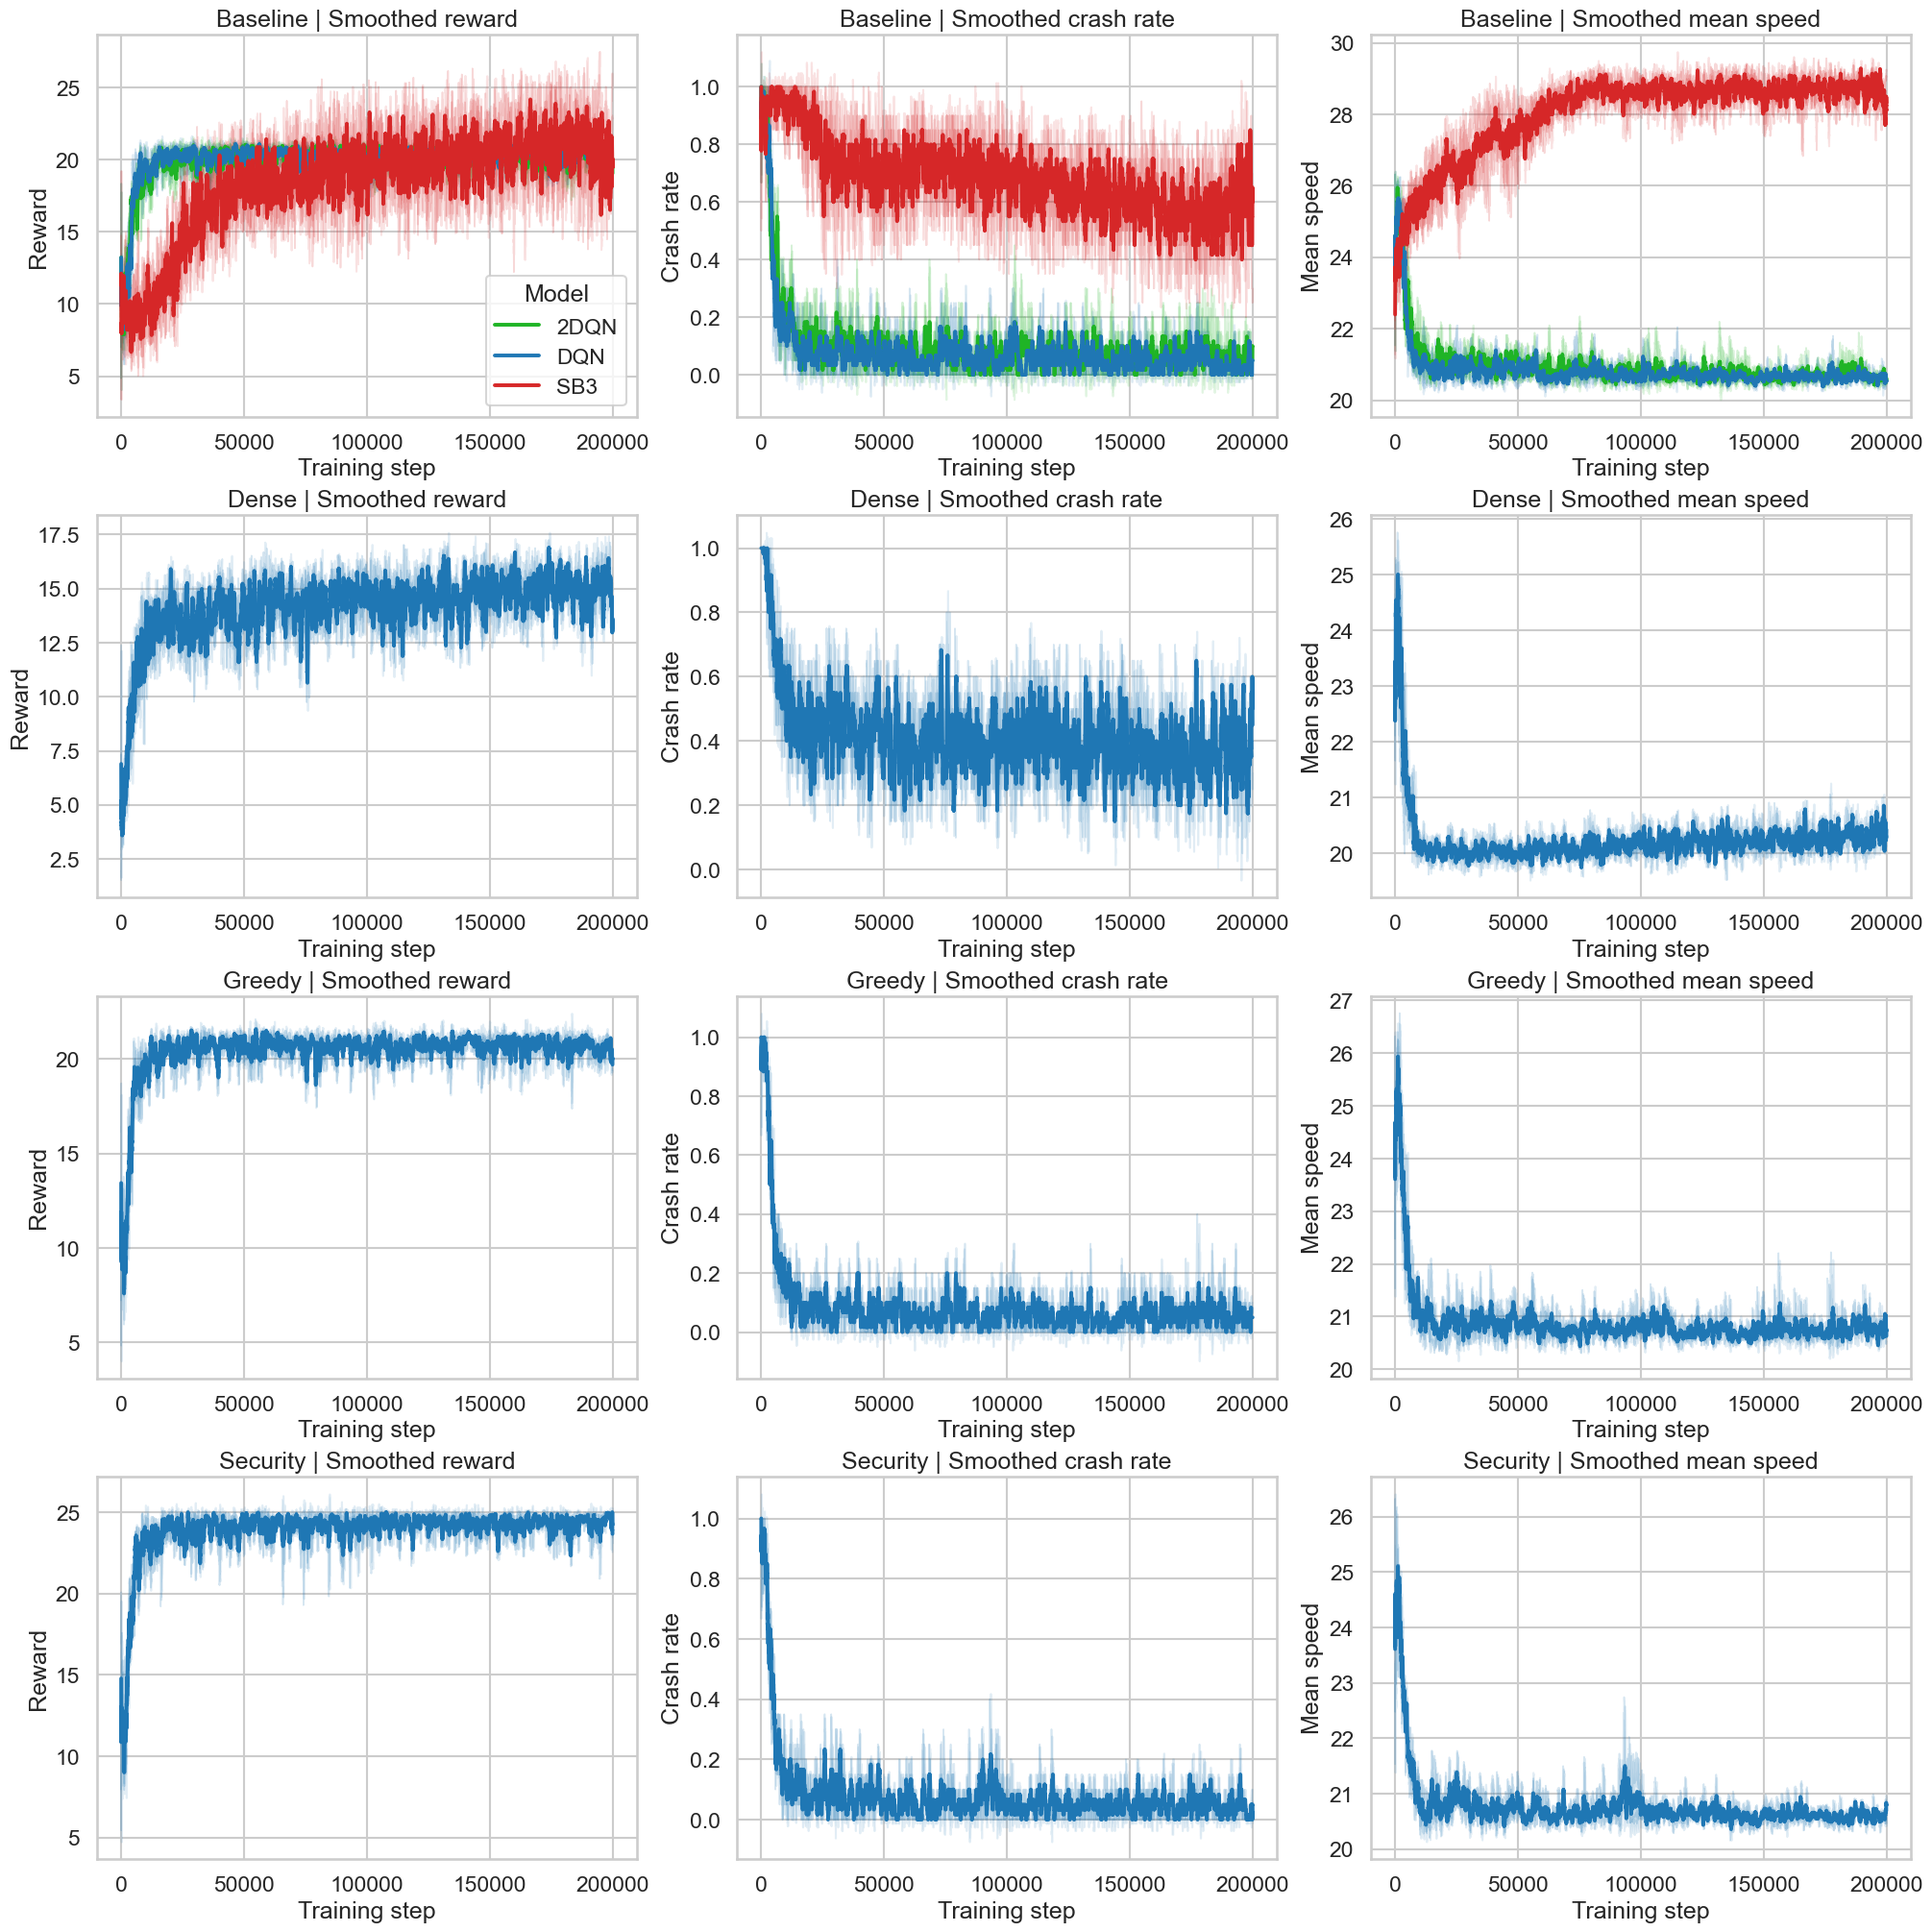

In [38]:
plot_data = (
    training_history.groupby(["config", "model", "episode"], as_index=False)
    .agg(
        reward_mean=("reward_smooth", "mean"),
        reward_std=("reward_smooth", "std"),
        crash_mean=("crash_rate_smooth", "mean"),
        crash_std=("crash_rate_smooth", "std"),
        speed_mean=("mean_speed_smooth", "mean"),
        speed_std=("mean_speed_smooth", "std"),
        step_mean=("total_steps", "mean"),
        n_runs=("seed", "nunique"),
    )
    .fillna(0.0)
)

configs = sorted(training_history["config"].unique())
palette = {"DQN": "#1f77b4", "SB3": "#d62728", "2DQN": "#1fb426"}
plot_specs = [
    ("reward", "Smoothed reward", "Reward"),
    ("crash", "Smoothed crash rate", "Crash rate"),
    ("speed", "Smoothed mean speed", "Mean speed"),
]

fig, axes = plt.subplots(
    nrows=len(configs),
    ncols=len(plot_specs),
    figsize=(20, 5 * len(configs)),
    sharex=False,
    constrained_layout=True,
)

if len(configs) == 1:
    axes = np.array([axes])

for row_idx, config in enumerate(configs):
    config_seed_data = training_history[training_history["config"] == config]
    config_mean_data = plot_data[plot_data["config"] == config]

    for col_idx, (metric_prefix, title, ylabel) in enumerate(plot_specs):
        ax = axes[row_idx, col_idx]
        mean_col = f"{metric_prefix}_mean"
        std_col = f"{metric_prefix}_std"
        smooth_col = {
            "reward": "reward_smooth",
            "crash": "crash_rate_smooth",
            "speed": "mean_speed_smooth",
        }[metric_prefix]

        for (model, seed), seed_df in config_seed_data.groupby(["model", "seed"]):
            ax.plot(
                seed_df["total_steps"],
                seed_df[smooth_col],
                color=palette[model],
                alpha=0.18,
                linewidth=1.2,
            )

        for model, model_df in config_mean_data.groupby("model"):
            model_df = model_df.sort_values("episode")
            ax.plot(
                model_df["step_mean"],
                model_df[mean_col],
                color=palette[model],
                linewidth=2.8,
                label=model,
            )
            ax.fill_between(
                model_df["step_mean"],
                model_df[mean_col] - model_df[std_col],
                model_df[mean_col] + model_df[std_col],
                color=palette[model],
                alpha=0.12,
            )

        ax.set_title(f"{config} | {title}")
        ax.set_xlabel("Training step")
        ax.set_ylabel(ylabel)
        if row_idx == 0 and col_idx == 0:
            ax.legend(title="Model")
        else:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()

plt.show()

Les graphes suivants ne correspondent pas à l’évaluation finale, mais à la fin de l’entraînement. Ils résument les derniers 10% des épisodes de training, avec au minimum 10 épisodes par run. Ils permettent d’observer le comportement appris en fin d’entraînement, mais les conclusions principales doivent être confirmées avec les résultats d’évaluation.

Visualiser le training global par seed permet de voir si une configuration DQN est régulièrement meilleure ou si son résultat dépend fortement de la seed. Cela montre aussi la stabilité de l’apprentissage sur toute la durée de l’entraînement, pas seulement le score final.

Visualiser seulement la fin de l’entraînement permet d’observer le comportement du modèle une fois qu’il a presque convergé. C’est utile pour comparer les configurations sur leur performance finale réelle, sans être trop influencé par les premiers épisodes où l’agent explore encore beaucoup.

,model,config,final_reward_mean,final_reward_std,final_crash_rate,final_offroad_rate,final_mean_speed
0,2DQN,Baseline,20.276,2.663,0.061,0.0,20.743
1,DQN,Baseline,20.419,2.238,0.037,0.0,20.646
5,SB3,Baseline,20.826,9.173,0.573,0.0,28.669
2,DQN,Dense,14.924,4.144,0.354,0.0,20.279
3,DQN,Greedy,20.557,2.623,0.059,0.0,20.775
4,DQN,Security,24.268,2.996,0.045,0.0,20.601


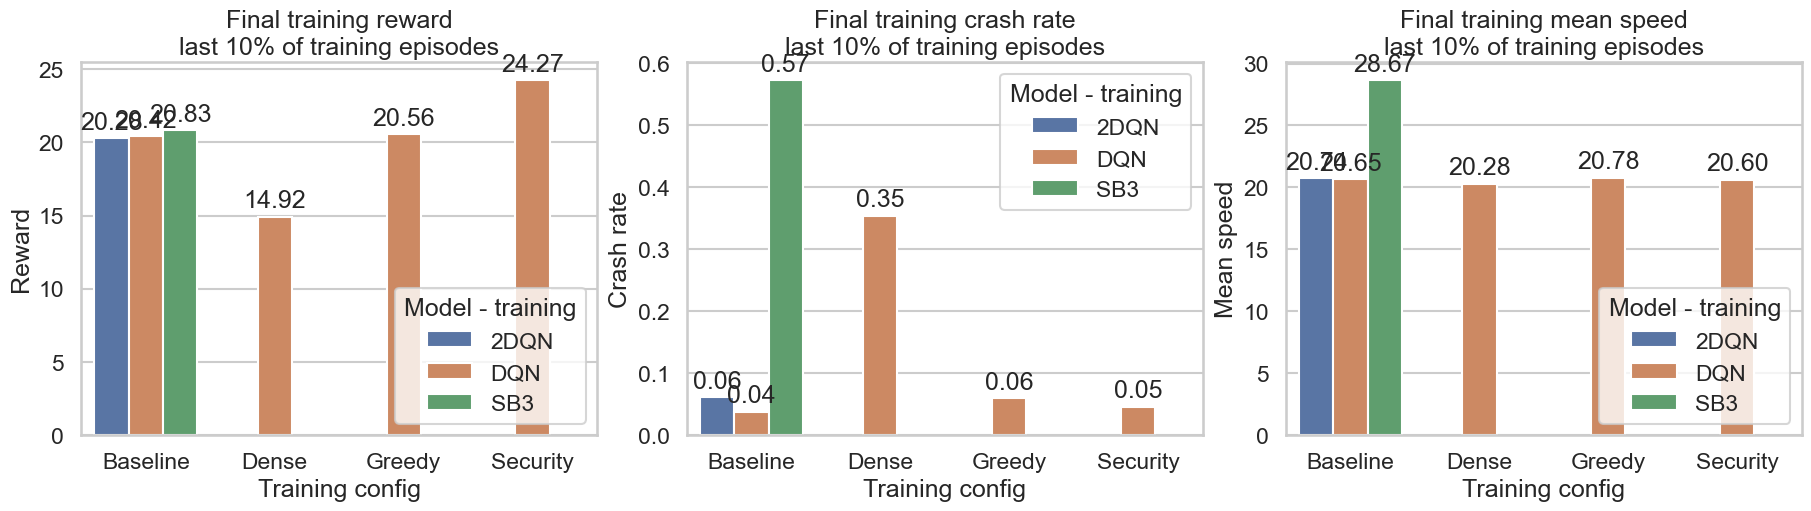

In [39]:
final_fraction = 0.1

late_training = training_history.sort_values(["model", "config", "seed", "episode"]).copy()
late_training["episodes_in_run"] = late_training.groupby(["model", "config", "seed"])[
    "episode"
].transform("size")
late_training["episodes_from_end"] = late_training.groupby(["model", "config", "seed"])[
    "episode"
].transform(lambda s: s.max() - s + 1)

late_training = late_training[
    late_training["episodes_from_end"]
    <= np.maximum(10, np.ceil(late_training["episodes_in_run"] * final_fraction))
].copy()

late_training_summary = (
    late_training.groupby(["model", "config"], as_index=False)
    .agg(
        final_reward_mean=("reward", "mean"),
        final_reward_std=("reward", "std"),
        final_crash_rate=("crashed", "mean"),
        final_offroad_rate=("offroad", "mean"),
        final_mean_speed=("mean_speed", "mean"),
    )
    .sort_values(["config", "model"])
)

display(late_training_summary.round(3))

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

plot_specs = [
    ("final_reward_mean", "Final training reward", "Reward"),
    ("final_crash_rate", "Final training crash rate", "Crash rate"),
    ("final_mean_speed", "Final training mean speed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    sns.barplot(
        data=late_training_summary,
        x="config",
        y=metric,
        hue="model",
        ax=ax,
    )
    ax.set_title(title + "\nlast 10% of training episodes")
    ax.set_xlabel("Training config")
    ax.set_ylabel(ylabel)
    ax.legend(title="Model - training")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()


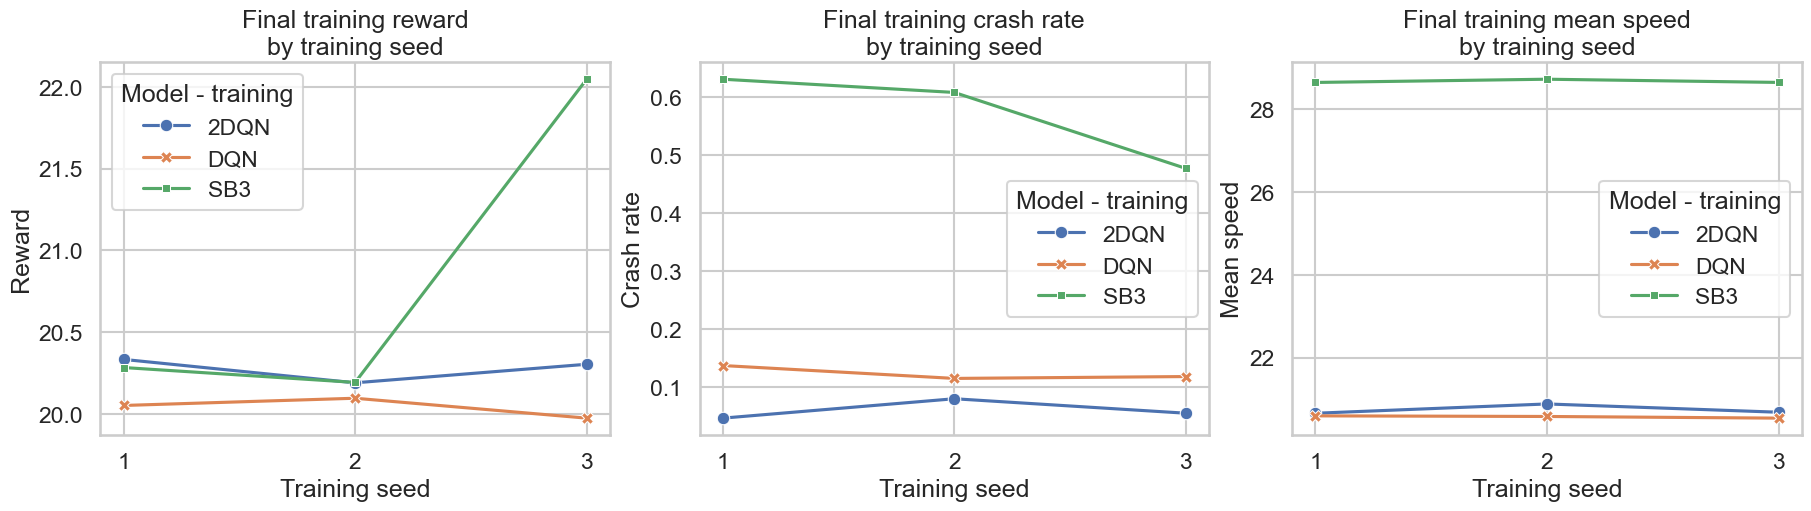

,model,config,seed,final_reward_mean,final_crash_rate,final_mean_speed
0,2DQN,Baseline,1,20.333,0.047,20.660
1,2DQN,Baseline,2,20.190,0.080,20.885
2,2DQN,Baseline,3,20.304,0.055,20.685
3,DQN,Baseline,1,20.403,0.038,20.649
4,DQN,Baseline,2,20.392,0.031,20.596
5,DQN,Baseline,3,20.461,0.043,20.694
15,SB3,Baseline,1,20.284,0.631,28.642
16,SB3,Baseline,2,20.193,0.608,28.720
17,SB3,Baseline,3,22.047,0.477,28.643
6,DQN,Dense,1,14.825,0.400,20.363


In [40]:
late_training_by_seed = (
    late_training.groupby(["model", "config", "seed"], as_index=False)
    .agg(
        final_reward_mean=("reward", "mean"),
        final_crash_rate=("crashed", "mean"),
        final_mean_speed=("mean_speed", "mean"),
    )
    .sort_values(["config", "model", "seed"])
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    sns.lineplot(
        data=late_training_by_seed,
        x="seed",
        y=metric,
        hue="model",
        style="model",
        markers=True,
        errorbar=None,
        dashes=False,
        ax=ax,
    )
    ax.set_title(title + "\nby training seed")
    ax.set_xlabel("Training seed")
    ax.set_ylabel(ylabel)
    ax.legend(title="Model - training")
    ax.set_xticks(sorted(late_training_by_seed["seed"].unique()))

plt.show()

display(late_training_by_seed.round(3))


## Comparaison DQN vs Stable-Baselines vs Double DQN (extension) à configuration, seeds et métriques identiques
***

### Chargement et traitement des données d'évaluation

In [9]:
summary_pattern = re.compile(
    r"data[\\/]evaluation[\\/](?P<model>[^\\/]+)[\\/](?P<config>[^\\/]+)[\\/]seed_(?P<train_seed>\d+)[\\/]evaluation_summary\.json$"
)

METRICS_TO_COMPARE = [
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "crash_rate",
    "offroad_rate",
    "mean_speed",
]
REQUIRED_COMPARISON_MODELS = {"DQN", "SB3", "2DQN"}
ALL_COMPARISON_MODELS = ["DQN", "SB3", "2DQN"]

summary_records = []
for summary_path in sorted((data_dir / "evaluation").rglob("evaluation_summary.json")):
    match = summary_pattern.search(str(summary_path))
    if match is None:
        continue

    metadata = match.groupdict()
    summary = CacheManager.load(summary_path)
    summary_records.append(
        {
            "model": metadata["model"].upper(),
            "config": metadata["config"].capitalize(),
            "train_seed": int(metadata["train_seed"]),
            **summary,
        }
    )

if not summary_records:
    raise ValueError("No evaluation_summary.json files found under data/evaluation")

evaluation_summary_df = pd.DataFrame(summary_records).sort_values(["config", "model", "train_seed"])

common_summary_pairs = (
    evaluation_summary_df.groupby(["config", "train_seed"])["model"]
    .agg(lambda models: REQUIRED_COMPARISON_MODELS.issubset(set(models)))
    .reset_index(name="has_required_models")
    .query("has_required_models")[["config", "train_seed"]]
)

paired_summary_df = evaluation_summary_df.merge(
    common_summary_pairs,
    on=["config", "train_seed"],
    how="inner",
)
paired_summary_df = paired_summary_df[paired_summary_df["model"].isin(ALL_COMPARISON_MODELS)].copy()

paired_inventory = (
    paired_summary_df.groupby(["config", "model"], as_index=False)
    .agg(
        n_training_seeds=("train_seed", "nunique"),
        train_seeds=("train_seed", lambda s: sorted(int(v) for v in s)),
        n_episodes_values=("n_episodes", lambda s: sorted(int(v) for v in set(s))),
    )
    .sort_values(["config", "model"])
)

print("Evaluation inventory: available paired evaluation runs.")
display(paired_inventory)


Evaluation inventory: available paired evaluation runs.


,config,model,n_training_seeds,train_seeds,n_episodes_values
0,Baseline,2DQN,3,"[1, 2, 3]",[50]
1,Baseline,DQN,3,"[1, 2, 3]",[50]
2,Baseline,SB3,3,"[1, 2, 3]",[50]


### Tableau par seed

In [10]:
paired_summary_comparison = paired_summary_df.pivot_table(
    index=["config", "train_seed"],
    columns="model",
    values=[*METRICS_TO_COMPARE, "n_episodes"],
)
paired_summary_comparison.columns = [
    f"{metric}_{model}" for metric, model in paired_summary_comparison.columns
]
paired_summary_comparison = paired_summary_comparison.reset_index()

for model in ["SB3", "2DQN"]:
    model_suffix = model.lower()
    for metric in METRICS_TO_COMPARE:
        paired_summary_comparison[f"delta_{metric}_dqn_minus_{model_suffix}"] = (
            paired_summary_comparison[f"{metric}_DQN"]
            - paired_summary_comparison[f"{metric}_{model}"]
        )

per_seed_display_columns = ["config", "train_seed"]
for metric in [
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "crash_rate",
    "offroad_rate",
    "mean_speed",
    "n_episodes",
]:
    per_seed_display_columns.extend([f"{metric}_DQN", f"{metric}_SB3", f"{metric}_2DQN"])

for model in ["SB3", "2DQN"]:
    model_suffix = model.lower()
    per_seed_display_columns.extend(
        [
            f"delta_mean_reward_dqn_minus_{model_suffix}",
            f"delta_crash_rate_dqn_minus_{model_suffix}",
            f"delta_mean_speed_dqn_minus_{model_suffix}",
        ]
    )

per_seed_comparison_table = paired_summary_comparison[per_seed_display_columns].sort_values(
    ["config", "train_seed"]
)

print("Evaluation results by training seed, before aggregation.")
display(per_seed_comparison_table.round(3))


Evaluation results by training seed, before aggregation.


,config,train_seed,mean_reward_DQN,mean_reward_SB3,mean_reward_2DQN,std_reward_DQN,std_reward_SB3,std_reward_2DQN,mean_episode_length_DQN,mean_episode_length_SB3,...,mean_speed_2DQN,n_episodes_DQN,n_episodes_SB3,n_episodes_2DQN,delta_mean_reward_dqn_minus_sb3,delta_crash_rate_dqn_minus_sb3,delta_mean_speed_dqn_minus_sb3,delta_mean_reward_dqn_minus_2dqn,delta_crash_rate_dqn_minus_2dqn,delta_mean_speed_dqn_minus_2dqn
0,Baseline,1,20.741,21.163,20.732,0.756,9.130,0.207,29.86,22.14,...,20.550,50.0,50.0,50.0,-0.422,-0.50,-8.141,0.009,0.02,0.156
1,Baseline,2,20.396,22.323,20.797,1.528,8.854,0.270,29.56,23.16,...,20.649,50.0,50.0,50.0,-1.926,-0.44,-8.694,-0.401,0.06,-0.149
2,Baseline,3,20.345,24.241,20.736,2.437,8.150,0.276,29.34,24.96,...,20.547,50.0,50.0,50.0,-3.896,-0.38,-8.623,-0.391,0.04,0.124


### Graphes par seed

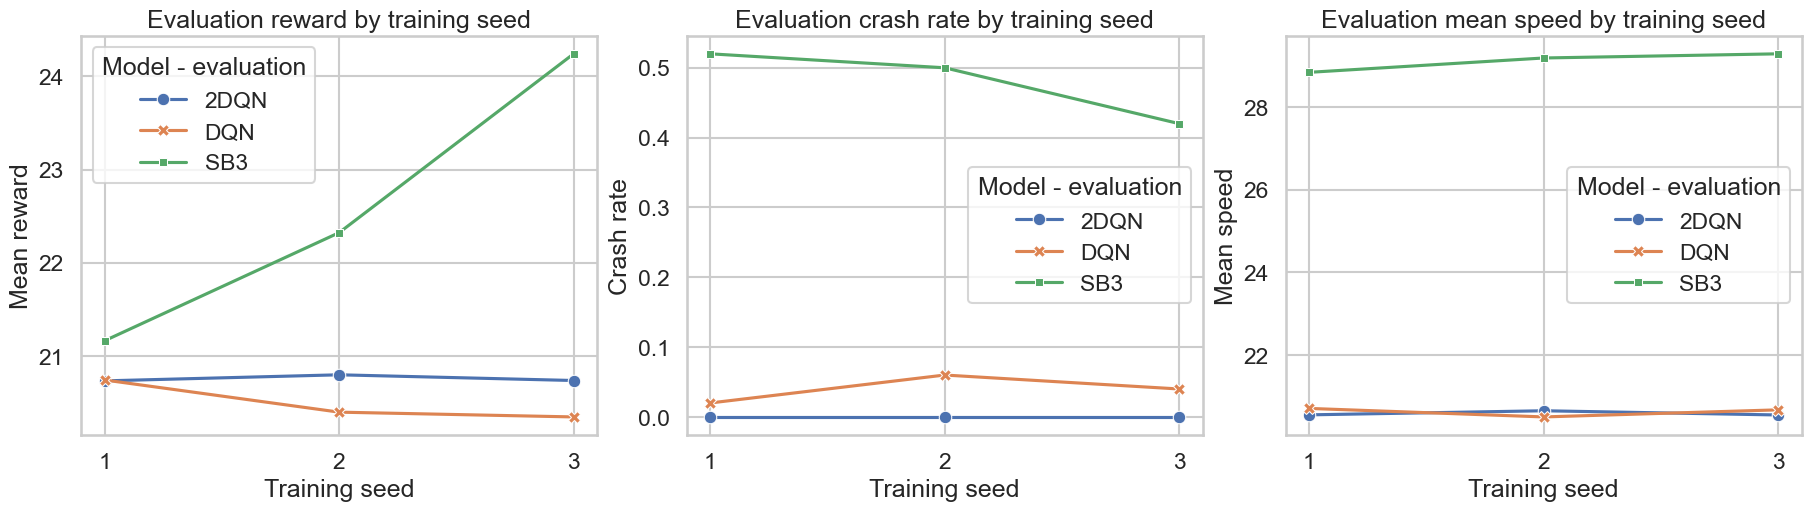

In [11]:
per_seed_plot_df = paired_summary_df.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

plot_specs = [
    ("mean_reward", "Evaluation reward by training seed", "Mean reward"),
    ("crash_rate", "Evaluation crash rate by training seed", "Crash rate"),
    ("mean_speed", "Evaluation mean speed by training seed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, plot_specs):
    sns.lineplot(
        data=per_seed_plot_df,
        x="train_seed",
        y=metric,
        hue="model",
        style="model",
        markers=True,
        dashes=False,
        errorbar=None,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Training seed")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(per_seed_plot_df["train_seed"].unique()))
    ax.legend(title="Model - evaluation")

plt.show()


### Tableau agrégé

In [12]:
summary_table = (
    paired_summary_df.groupby(["config", "model"], as_index=False)
    .agg(
        n_training_seeds=("train_seed", "nunique"),
        reward_mean=("mean_reward", "mean"),
        reward_std_across_seeds=("mean_reward", "std"),
        mean_internal_std_reward=("std_reward", "mean"),
        episode_length_mean=("mean_episode_length", "mean"),
        crash_rate_mean=("crash_rate", "mean"),
        offroad_rate_mean=("offroad_rate", "mean"),
        mean_speed_mean=("mean_speed", "mean"),
        n_episodes=("n_episodes", "mean"),
    )
    .sort_values(["config", "model"])
    .fillna(0.0)
)

comparison_agg = {
    "paired_training_seeds": ("train_seed", "nunique"),
    "reward_delta_mean_dqn_minus_sb3": ("delta_mean_reward_dqn_minus_sb3", "mean"),
    "reward_delta_std_dqn_minus_sb3": ("delta_mean_reward_dqn_minus_sb3", "std"),
    "std_reward_delta_mean_dqn_minus_sb3": ("delta_std_reward_dqn_minus_sb3", "mean"),
    "episode_length_delta_mean_dqn_minus_sb3": (
        "delta_mean_episode_length_dqn_minus_sb3",
        "mean",
    ),
    "crash_rate_delta_mean_dqn_minus_sb3": ("delta_crash_rate_dqn_minus_sb3", "mean"),
    "offroad_rate_delta_mean_dqn_minus_sb3": ("delta_offroad_rate_dqn_minus_sb3", "mean"),
    "mean_speed_delta_mean_dqn_minus_sb3": ("delta_mean_speed_dqn_minus_sb3", "mean"),
    "reward_delta_mean_dqn_minus_2dqn": ("delta_mean_reward_dqn_minus_2dqn", "mean"),
    "reward_delta_std_dqn_minus_2dqn": ("delta_mean_reward_dqn_minus_2dqn", "std"),
    "std_reward_delta_mean_dqn_minus_2dqn": ("delta_std_reward_dqn_minus_2dqn", "mean"),
    "episode_length_delta_mean_dqn_minus_2dqn": (
        "delta_mean_episode_length_dqn_minus_2dqn",
        "mean",
    ),
    "crash_rate_delta_mean_dqn_minus_2dqn": ("delta_crash_rate_dqn_minus_2dqn", "mean"),
    "offroad_rate_delta_mean_dqn_minus_2dqn": ("delta_offroad_rate_dqn_minus_2dqn", "mean"),
    "mean_speed_delta_mean_dqn_minus_2dqn": ("delta_mean_speed_dqn_minus_2dqn", "mean"),
    "n_episodes_dqn": ("n_episodes_DQN", "mean"),
    "n_episodes_sb3": ("n_episodes_SB3", "mean"),
    "n_episodes_2dqn": ("n_episodes_2DQN", "mean"),
}

comparison_table_json = (
    paired_summary_comparison.groupby("config", as_index=False)
    .agg(**comparison_agg)
    .sort_values("config")
    .fillna(0.0)
)

comparison_table_json["reward_delta_mean"] = comparison_table_json[
    "reward_delta_mean_dqn_minus_sb3"
]
comparison_table_json["crash_rate_delta_mean"] = comparison_table_json[
    "crash_rate_delta_mean_dqn_minus_sb3"
]
comparison_table_json["mean_speed_delta_mean"] = comparison_table_json[
    "mean_speed_delta_mean_dqn_minus_sb3"
]

comparison_table_json["better_model_on_reward_dqn_vs_sb3"] = np.where(
    comparison_table_json["reward_delta_mean_dqn_minus_sb3"] > 0,
    "DQN",
    np.where(comparison_table_json["reward_delta_mean_dqn_minus_sb3"] < 0, "SB3", "Tie"),
)
comparison_table_json["better_model_on_safety_dqn_vs_sb3"] = np.where(
    comparison_table_json["crash_rate_delta_mean_dqn_minus_sb3"] < 0,
    "DQN",
    np.where(comparison_table_json["crash_rate_delta_mean_dqn_minus_sb3"] > 0, "SB3", "Tie"),
)
comparison_table_json["better_model_on_reward_dqn_vs_2dqn"] = np.where(
    comparison_table_json["reward_delta_mean_dqn_minus_2dqn"] > 0,
    "DQN",
    np.where(comparison_table_json["reward_delta_mean_dqn_minus_2dqn"] < 0, "2DQN", "Tie"),
)
comparison_table_json["better_model_on_safety_dqn_vs_2dqn"] = np.where(
    comparison_table_json["crash_rate_delta_mean_dqn_minus_2dqn"] < 0,
    "DQN",
    np.where(comparison_table_json["crash_rate_delta_mean_dqn_minus_2dqn"] > 0, "2DQN", "Tie"),
)

comparison_table_json["episode_budget_check"] = np.where(
    comparison_table_json[["n_episodes_dqn", "n_episodes_sb3", "n_episodes_2dqn"]]
    .eq(50)
    .all(axis=1),
    "OK: 50 episodes",
    "Provisional: not 50 episodes yet",
)

print("Evaluation summary table aggregated across training seeds.")
display(summary_table.round(3))

print("Final comparison based on aggregated evaluation results.")
display(comparison_table_json.round(3))


Evaluation summary table aggregated across training seeds.


,config,model,n_training_seeds,reward_mean,reward_std_across_seeds,mean_internal_std_reward,episode_length_mean,crash_rate_mean,offroad_rate_mean,mean_speed_mean,n_episodes
0,Baseline,2DQN,3,20.755,0.037,0.251,30.000,0.00,0.0,20.582,50.0
1,Baseline,DQN,3,20.494,0.215,1.574,29.587,0.04,0.0,20.625,50.0
2,Baseline,SB3,3,22.576,1.555,8.711,23.420,0.48,0.0,29.111,50.0


Final comparison based on aggregated evaluation results.


,config,paired_training_seeds,reward_delta_mean_dqn_minus_sb3,reward_delta_std_dqn_minus_sb3,std_reward_delta_mean_dqn_minus_sb3,episode_length_delta_mean_dqn_minus_sb3,crash_rate_delta_mean_dqn_minus_sb3,offroad_rate_delta_mean_dqn_minus_sb3,mean_speed_delta_mean_dqn_minus_sb3,reward_delta_mean_dqn_minus_2dqn,...,n_episodes_sb3,n_episodes_2dqn,reward_delta_mean,crash_rate_delta_mean,mean_speed_delta_mean,better_model_on_reward_dqn_vs_sb3,better_model_on_safety_dqn_vs_sb3,better_model_on_reward_dqn_vs_2dqn,better_model_on_safety_dqn_vs_2dqn,episode_budget_check
0,Baseline,3,-2.082,1.742,-7.138,6.167,-0.44,0.0,-8.486,-0.261,...,50.0,50.0,-2.082,-0.44,-8.486,SB3,DQN,2DQN,2DQN,OK: 50 episodes


### Graphes agrégés

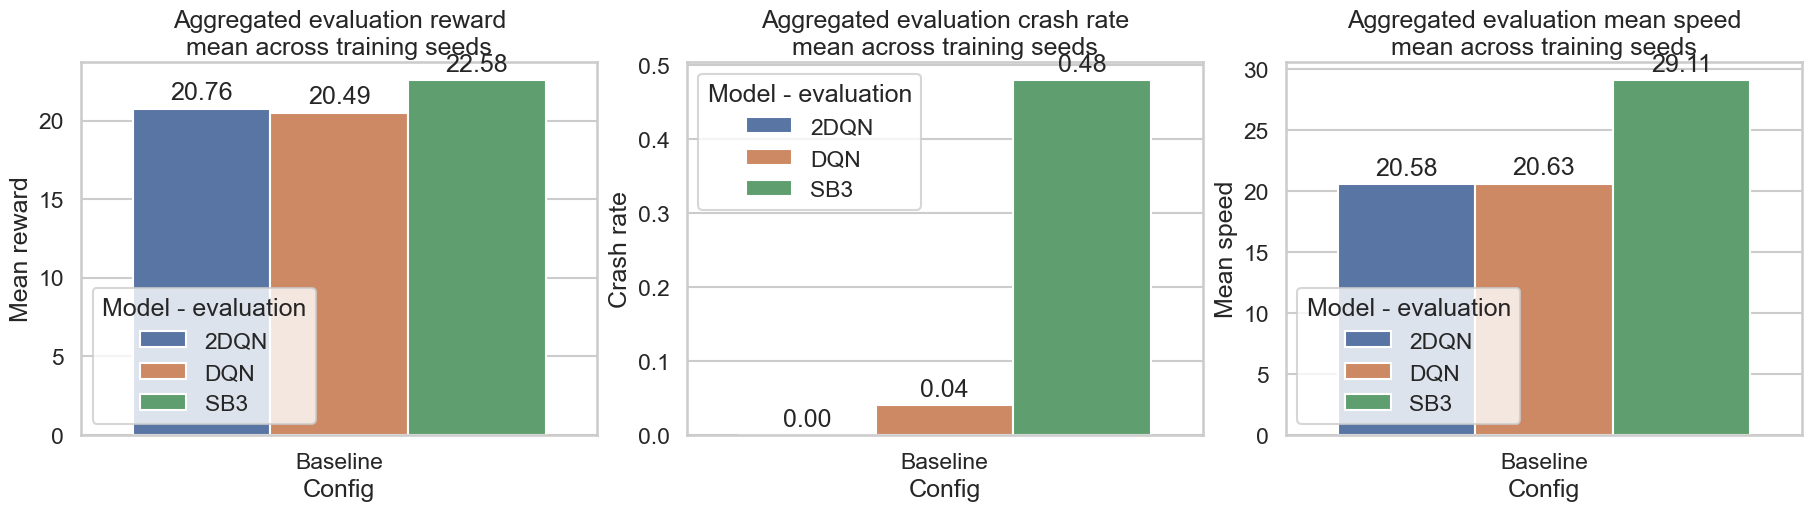

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

aggregate_plot_specs = [
    ("reward_mean", "Aggregated evaluation reward", "Mean reward"),
    ("crash_rate_mean", "Aggregated evaluation crash rate", "Crash rate"),
    ("mean_speed_mean", "Aggregated evaluation mean speed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, aggregate_plot_specs):
    sns.barplot(
        data=summary_table,
        x="config",
        y=metric,
        hue="model",
        ax=ax,
    )
    ax.set_title(title + "\nmean across training seeds")
    ax.set_xlabel("Config")
    ax.set_ylabel(ylabel)
    ax.legend(title="Model - evaluation")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()


### Etude du meilleur modèle selon reward et sécurité

In [51]:
model_comparison_ranking = summary_table.copy()

model_comparison_ranking["reward_rank"] = model_comparison_ranking.groupby("config")[
    "reward_mean"
].rank(ascending=False, method="min")

model_comparison_ranking["safety_rank"] = model_comparison_ranking.groupby("config")[
    "crash_rate_mean"
].rank(ascending=True, method="min")

model_comparison_ranking["speed_rank"] = model_comparison_ranking.groupby("config")[
    "mean_speed_mean"
].rank(ascending=False, method="min")

model_comparison_ranking["overall_rank_score"] = (
    model_comparison_ranking["reward_rank"]
    + model_comparison_ranking["safety_rank"]
    + model_comparison_ranking["speed_rank"]
)

model_comparison_ranking = model_comparison_ranking.sort_values(
    ["config", "overall_rank_score", "reward_rank", "safety_rank"]
)

print("Model ranking on evaluation results.")
print("Lower rank is better. Safety rank is based on lower crash rate.")
display(
    model_comparison_ranking[
        [
            "config",
            "model",
            "reward_mean",
            "crash_rate_mean",
            "mean_speed_mean",
            "reward_rank",
            "safety_rank",
            "speed_rank",
            "overall_rank_score",
        ]
    ].round(3)
)


Model ranking on evaluation results.
Lower rank is better. Safety rank is based on lower crash rate.


,config,model,reward_mean,crash_rate_mean,mean_speed_mean,reward_rank,safety_rank,speed_rank,overall_rank_score
2,Baseline,SB3,22.576,0.48,29.111,1.0,3.0,1.0,5.0
0,Baseline,2DQN,20.755,0.00,20.582,2.0,1.0,3.0,6.0
1,Baseline,DQN,20.494,0.04,20.625,3.0,2.0,2.0,7.0


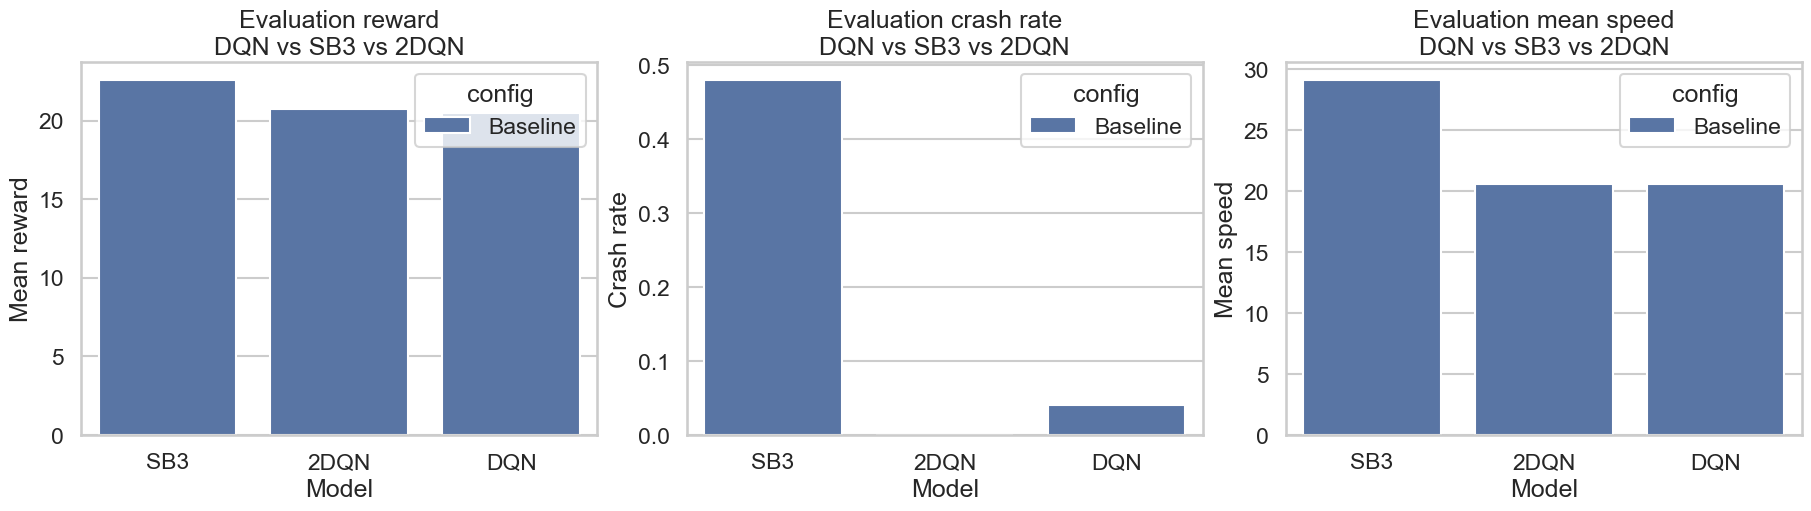

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

ranking_plot_specs = [
    ("reward_mean", "Evaluation reward", "Mean reward"),
    ("crash_rate_mean", "Evaluation crash rate", "Crash rate"),
    ("mean_speed_mean", "Evaluation mean speed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, ranking_plot_specs):
    sns.barplot(
        data=model_comparison_ranking,
        x="model",
        y=metric,
        hue="config",
        ax=ax,
    )
    ax.set_title(title + "\nDQN vs SB3 vs 2DQN")
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()


Le ranking montre que SB3 obtient le meilleur compromis global selon la somme des rangs, principalement grâce à son reward et sa vitesse très élevés. Cependant, ce résultat doit être nuancé : SB3 a aussi le pire niveau de sécurité, avec un crash rate de 48%. À l’inverse, 2DQN est le modèle le plus sûr, avec un crash rate nul, mais il est plus lent et obtient un reward plus faible. DQN se situe entre les deux en sécurité, mais il n’est meilleur sur aucun des critères. Ainsi, si l’objectif principal est la performance et la vitesse, SB3 est le meilleur choix. Si l’objectif principal est la sécurité, 2DQN est préférable.

## Étude des différentes configuration (extension) : training et évaluation
***

### Training

#### Traitement des données DQN training par configuration

In [15]:
DQN_CONFIGS_TO_COMPARE = ["Baseline", "Greedy", "Dense", "Security"]
DQN_TRAINING_METRICS = ["reward", "crashed", "offroad", "mean_speed"]

dqn_training_config_history = training_history[
    (training_history["model"] == "DQN") & (training_history["config"].isin(DQN_CONFIGS_TO_COMPARE))
].copy()

if dqn_training_config_history.empty:
    raise ValueError("No DQN training history found for the selected configurations.")

dqn_training_config_inventory = (
    dqn_training_config_history.groupby(["config", "seed"], as_index=False)
    .agg(
        n_episodes=("episode", "nunique"),
        max_training_step=("total_steps", "max"),
        reward_mean=("reward", "mean"),
        crash_rate=("crashed", "mean"),
        offroad_rate=("offroad", "mean"),
        mean_speed=("mean_speed", "mean"),
    )
    .sort_values(["config", "seed"])
)

display(dqn_training_config_inventory.round(3))


,config,seed,n_episodes,max_training_step,reward_mean,crash_rate,offroad_rate,mean_speed
0,Baseline,1,7040,200000,19.775,0.103,0.0,20.912
1,Baseline,2,7024,200000,19.867,0.096,0.0,20.963
2,Baseline,3,7016,200000,19.870,0.102,0.0,20.924
3,Dense,1,8194,200000,13.774,0.443,0.0,20.372
4,Dense,2,8150,200000,13.840,0.433,0.0,20.390
5,Dense,3,7001,170512,13.609,0.432,0.0,20.234
6,Greedy,1,7014,200000,20.168,0.101,0.0,20.954
7,Greedy,2,7047,200000,20.191,0.106,0.0,21.044
8,Greedy,3,7003,200000,20.180,0.095,0.0,20.886
9,Security,1,6970,200000,23.756,0.084,0.0,20.794


#### Courbes training par configuration et seed

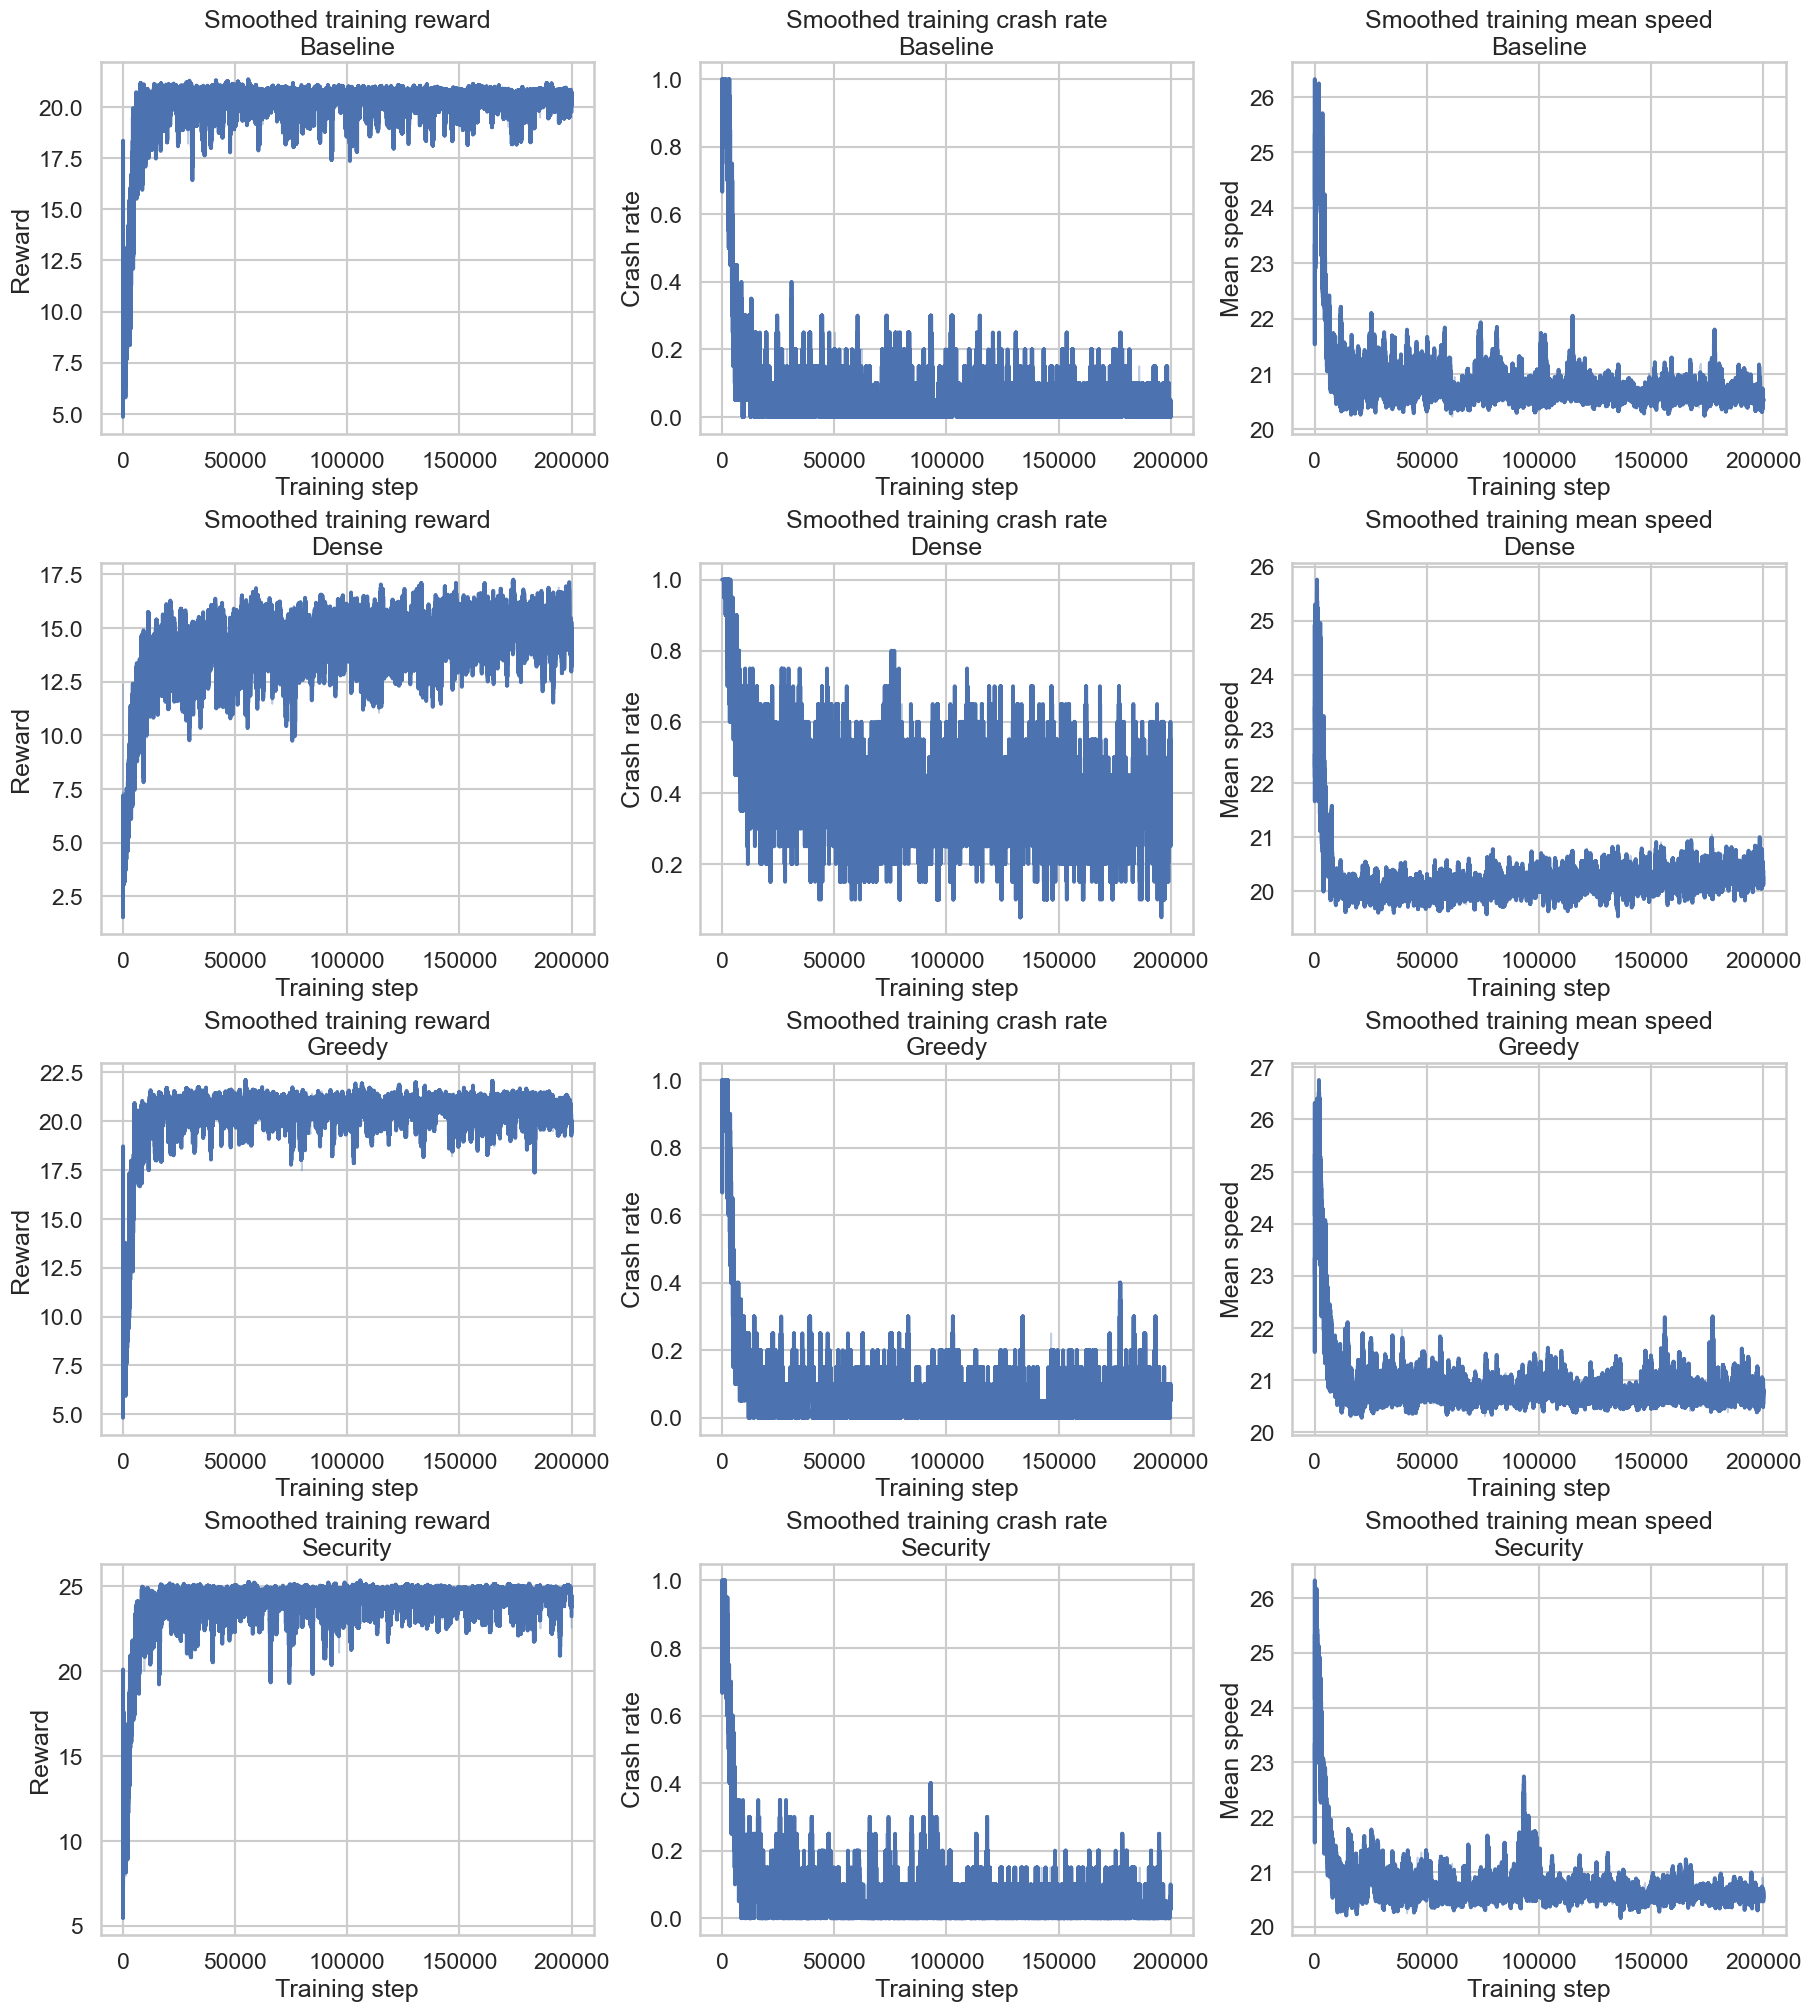

In [ ]:
configs = list(dqn_training_config_history["config"].dropna().unique())

fig, axes = plt.subplots(
    len(configs),
    3,
    figsize=(18, 5 * len(configs)),
    constrained_layout=True,
    squeeze=False,
)

training_curve_specs = [
    ("reward_smooth", "Smoothed training reward", "Reward"),
    ("crash_rate_smooth", "Smoothed training crash rate", "Crash rate"),
    ("mean_speed_smooth", "Smoothed training mean speed", "Mean speed"),
]

for row, config in enumerate(configs):
    config_data = dqn_training_config_history[dqn_training_config_history["config"] == config]
    for col, (metric, title, ylabel) in enumerate(training_curve_specs):
        ax = axes[row, col]
        sns.lineplot(
            data=config_data,
            x="total_steps",
            y=metric,
            units="seed",
            estimator=None,
            alpha=0.35,
            linewidth=1.2,
            color="C0",
            ax=ax,
        )
        sns.lineplot(
            data=config_data,
            x="total_steps",
            y=metric,
            estimator="mean",
            errorbar=None,
            linewidth=2.8,
            color="C0",
            ax=ax,
        )
        ax.set_title(f"{title}\n{config}")
        ax.set_xlabel("Training step")
        ax.set_ylabel(ylabel)

plt.show()

#### Résumé global training par configuration

In [17]:
dqn_training_config_summary = (
    dqn_training_config_history.groupby("config", as_index=False)
    .agg(
        n_training_seeds=("seed", "nunique"),
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        episode_length_mean=("length", "mean"),
        crash_rate=("crashed", "mean"),
        offroad_rate=("offroad", "mean"),
        mean_speed=("mean_speed", "mean"),
        observed_steps_mean=("total_steps", "max"),
    )
    .sort_values("config")
    .fillna(0.0)
)

print("DQN training summary by configuration, using all training episodes.")
display(dqn_training_config_summary.round(3))


DQN training summary by configuration, using all training episodes.


,config,n_training_seeds,reward_mean,reward_std,episode_length_mean,crash_rate,offroad_rate,mean_speed,observed_steps_mean
0,Baseline,3,19.837,3.652,28.463,0.100,0.0,20.933,200000
1,Dense,3,13.748,4.944,24.438,0.436,0.0,20.337,200000
2,Greedy,3,20.179,3.729,28.485,0.101,0.0,20.961,200000
3,Security,3,23.689,4.271,28.620,0.091,0.0,20.822,200000


#### Graphes du résumé global training

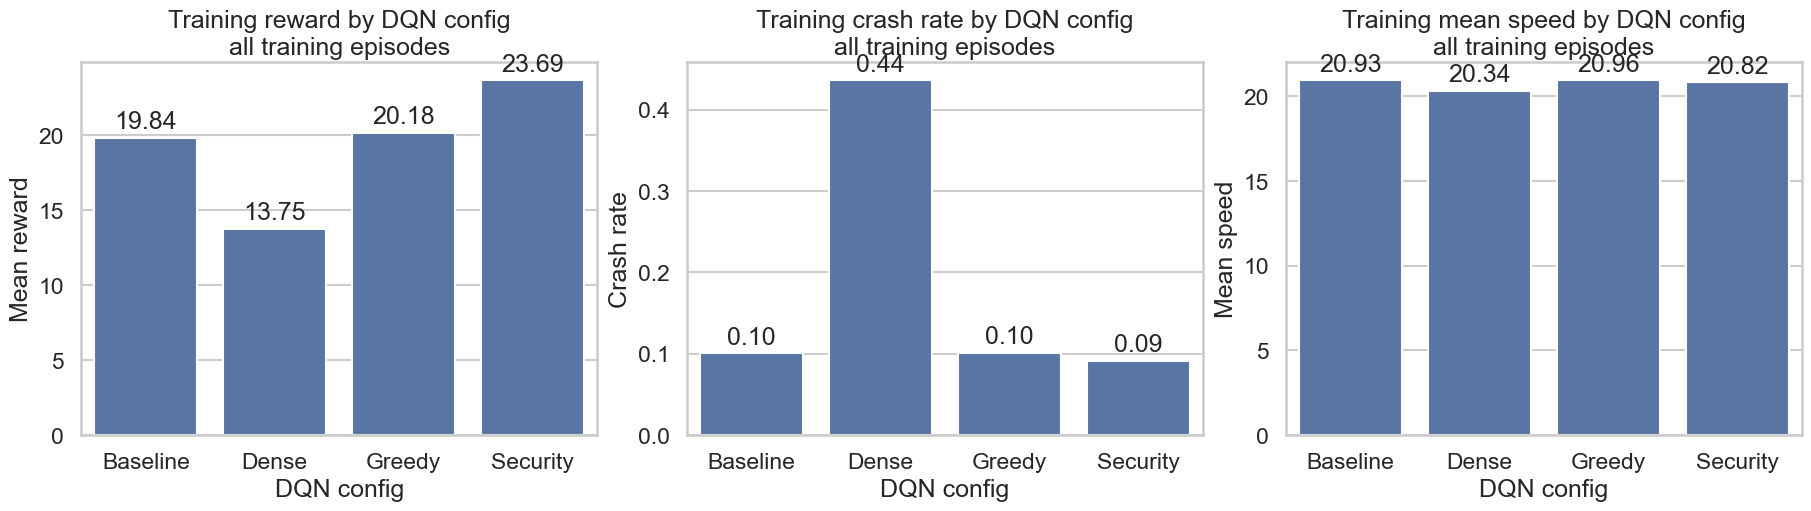

In [18]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

summary_plot_specs = [
    ("reward_mean", "Training reward by DQN config", "Mean reward"),
    ("crash_rate", "Training crash rate by DQN config", "Crash rate"),
    ("mean_speed", "Training mean speed by DQN config", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, summary_plot_specs):
    sns.barplot(
        data=dqn_training_config_summary,
        x="config",
        y=metric,
        ax=ax,
    )
    ax.set_title(title + "\nall training episodes")
    ax.set_xlabel("DQN config")
    ax.set_ylabel(ylabel)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()


#### Résumé et graphes de fin d’entraînement par seed

DQN late-training summary by configuration and seed.
Late training = last 10% of training episodes, with at least 10 episodes per run.


,config,seed,final_reward_mean,final_reward_std,final_crash_rate,final_offroad_rate,final_mean_speed,n_final_episodes
0,Baseline,1,20.403,2.213,0.038,0.0,20.649,704
1,Baseline,2,20.392,2.399,0.031,0.0,20.596,703
2,Baseline,3,20.461,2.095,0.043,0.0,20.694,702
3,Dense,1,14.825,4.284,0.400,0.0,20.363,820
4,Dense,2,15.099,4.026,0.331,0.0,20.286,815
5,Dense,3,14.835,4.113,0.327,0.0,20.173,701
6,Greedy,1,20.508,2.489,0.080,0.0,20.812,702
7,Greedy,2,20.603,2.620,0.052,0.0,20.776,705
8,Greedy,3,20.559,2.757,0.046,0.0,20.738,701
9,Security,1,24.471,2.662,0.032,0.0,20.565,697


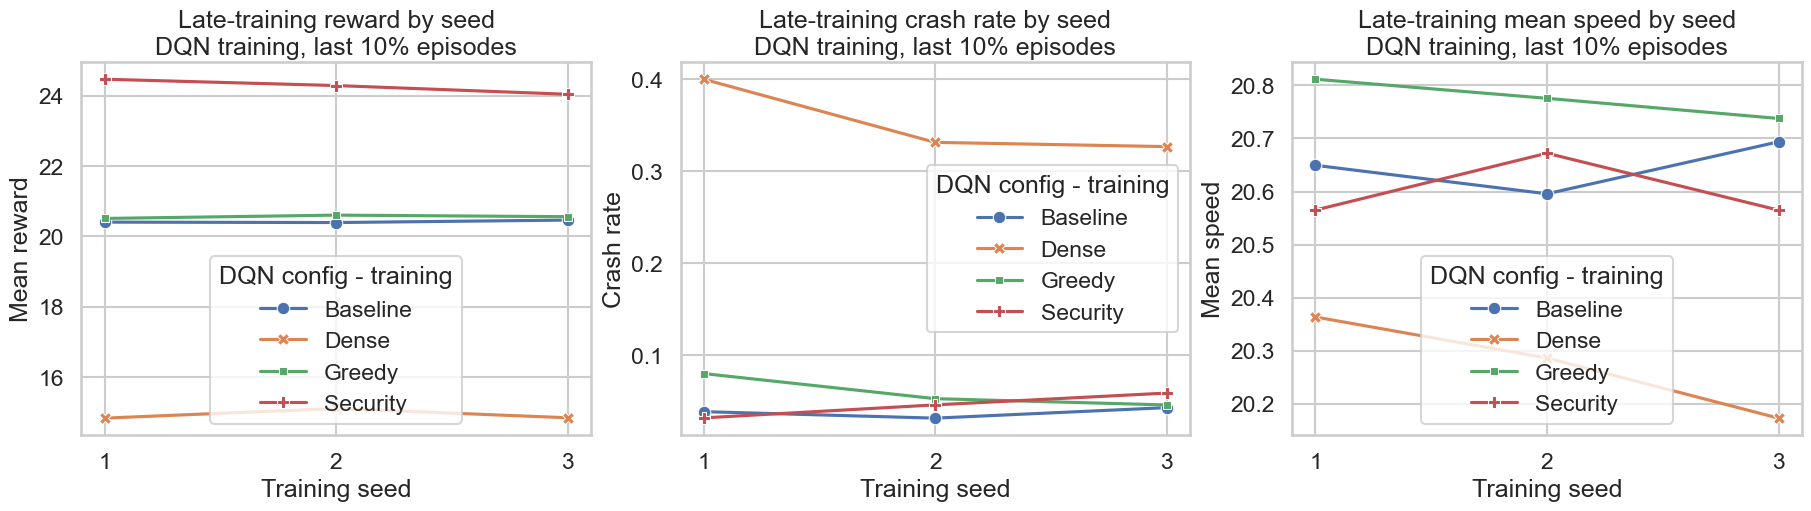

In [19]:
final_fraction = 0.1

dqn_late_training_config_history = dqn_training_config_history.sort_values(
    ["config", "seed", "episode"]
).copy()

dqn_late_training_config_history["episodes_in_run"] = dqn_late_training_config_history.groupby(
    ["config", "seed"]
)["episode"].transform("size")
dqn_late_training_config_history["episodes_from_end"] = dqn_late_training_config_history.groupby(
    ["config", "seed"]
)["episode"].transform(lambda s: s.max() - s + 1)

dqn_late_training_config_history = dqn_late_training_config_history[
    dqn_late_training_config_history["episodes_from_end"]
    <= np.maximum(
        10,
        np.ceil(dqn_late_training_config_history["episodes_in_run"] * final_fraction),
    )
].copy()

dqn_late_training_by_seed = (
    dqn_late_training_config_history.groupby(["config", "seed"], as_index=False)
    .agg(
        final_reward_mean=("reward", "mean"),
        final_reward_std=("reward", "std"),
        final_crash_rate=("crashed", "mean"),
        final_offroad_rate=("offroad", "mean"),
        final_mean_speed=("mean_speed", "mean"),
        n_final_episodes=("episode", "nunique"),
    )
    .sort_values(["config", "seed"])
    .fillna(0.0)
)

print("DQN late-training summary by configuration and seed.")
print("Late training = last 10% of training episodes, with at least 10 episodes per run.")
display(dqn_late_training_by_seed.round(3))

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

late_training_plot_specs = [
    ("final_reward_mean", "Late-training reward by seed", "Mean reward"),
    ("final_crash_rate", "Late-training crash rate by seed", "Crash rate"),
    ("final_mean_speed", "Late-training mean speed by seed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, late_training_plot_specs):
    sns.lineplot(
        data=dqn_late_training_by_seed,
        x="seed",
        y=metric,
        hue="config",
        style="config",
        markers=True,
        dashes=False,
        errorbar=None,
        ax=ax,
    )
    ax.set_title(title + "\nDQN training, last 10% episodes")
    ax.set_xlabel("Training seed")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(dqn_late_training_by_seed["seed"].unique()))
    ax.legend(title="DQN config - training")

plt.show()


#### Résumé et graphes agrégés de fin d’entraînement

DQN late-training summary aggregated across seeds.


,config,n_training_seeds,final_reward_mean,final_reward_std_across_seeds,final_crash_rate_mean,final_offroad_rate_mean,final_mean_speed_mean
0,Baseline,3,20.419,0.037,0.037,0.0,20.646
1,Dense,3,14.920,0.156,0.353,0.0,20.274
2,Greedy,3,20.557,0.047,0.059,0.0,20.775
3,Security,3,24.268,0.215,0.045,0.0,20.601


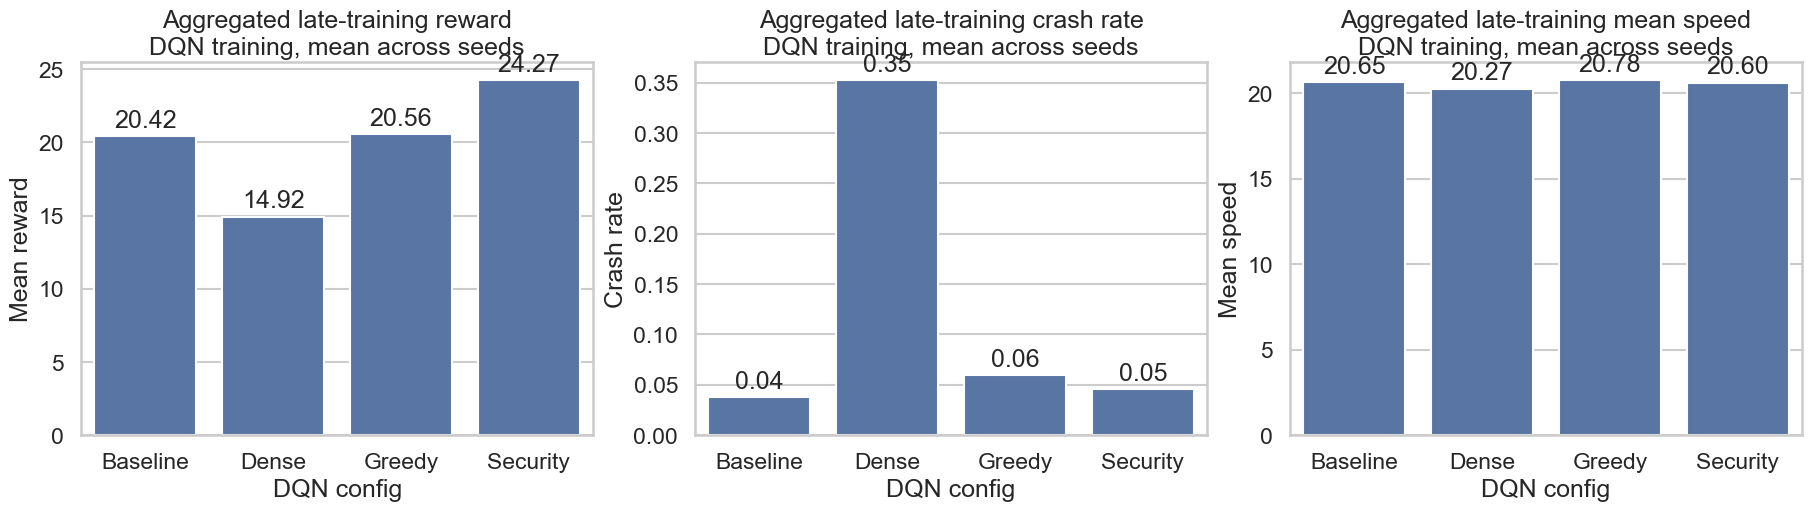

In [24]:
dqn_late_training_config_summary = (
    dqn_late_training_by_seed.groupby("config", as_index=False)
    .agg(
        n_training_seeds=("seed", "nunique"),
        final_reward_mean=("final_reward_mean", "mean"),
        final_reward_std_across_seeds=("final_reward_mean", "std"),
        final_crash_rate_mean=("final_crash_rate", "mean"),
        final_offroad_rate_mean=("final_offroad_rate", "mean"),
        final_mean_speed_mean=("final_mean_speed", "mean"),
    )
    .sort_values("config")
    .fillna(0.0)
)

print("DQN late-training summary aggregated across seeds.")
display(dqn_late_training_config_summary.round(3))


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

aggregate_late_plot_specs = [
    ("final_reward_mean", "Aggregated late-training reward", "Mean reward"),
    ("final_crash_rate_mean", "Aggregated late-training crash rate", "Crash rate"),
    ("final_mean_speed_mean", "Aggregated late-training mean speed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, aggregate_late_plot_specs):
    sns.barplot(
        data=dqn_late_training_config_summary,
        x="config",
        y=metric,
        ax=ax,
    )
    ax.set_title(title + "\nDQN training, mean across seeds")
    ax.set_xlabel("DQN config")
    ax.set_ylabel(ylabel)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()


### Evaluation

#### Traitement des données d’évaluation DQN par configuration

In [42]:
DQN_CONFIGS_TO_COMPARE = ["Baseline", "Greedy", "Dense", "Security"]
DQN_EVALUATION_METRICS = [
    "mean_reward",
    "std_reward",
    "mean_episode_length",
    "crash_rate",
    "offroad_rate",
    "mean_speed",
]

dqn_eval_summary_df = evaluation_summary_df[
    (evaluation_summary_df["model"] == "DQN")
    & (evaluation_summary_df["config"].isin(DQN_CONFIGS_TO_COMPARE))
].copy()

if dqn_eval_summary_df.empty:
    raise ValueError("No DQN evaluation summaries found for the selected configurations.")

dqn_eval_summary_df = dqn_eval_summary_df.sort_values(["config", "train_seed"])

display(dqn_eval_summary_df.round(3))


,model,config,train_seed,mean_reward,std_reward,mean_episode_length,crash_rate,offroad_rate,mean_speed,n_episodes
3,DQN,Baseline,1,20.741,0.756,29.86,0.02,0.0,20.705,50
4,DQN,Baseline,2,20.396,1.528,29.56,0.06,0.0,20.499,50
5,DQN,Baseline,3,20.345,2.437,29.34,0.04,0.0,20.671,50
6,DQN,Dense,1,20.455,0.000,30.00,0.00,0.0,20.034,50
7,DQN,Dense,2,20.455,0.000,30.00,0.00,0.0,20.034,50
8,DQN,Dense,3,20.455,0.000,30.00,0.00,0.0,20.034,50
9,DQN,Greedy,1,20.761,0.265,30.00,0.00,0.0,20.601,50
10,DQN,Greedy,2,20.809,0.646,29.92,0.02,0.0,20.714,50
11,DQN,Greedy,3,20.094,3.036,28.92,0.08,0.0,20.799,50
12,DQN,Security,1,20.675,0.200,30.00,0.00,0.0,20.447,50


#### Graphes d’évaluation par seed 

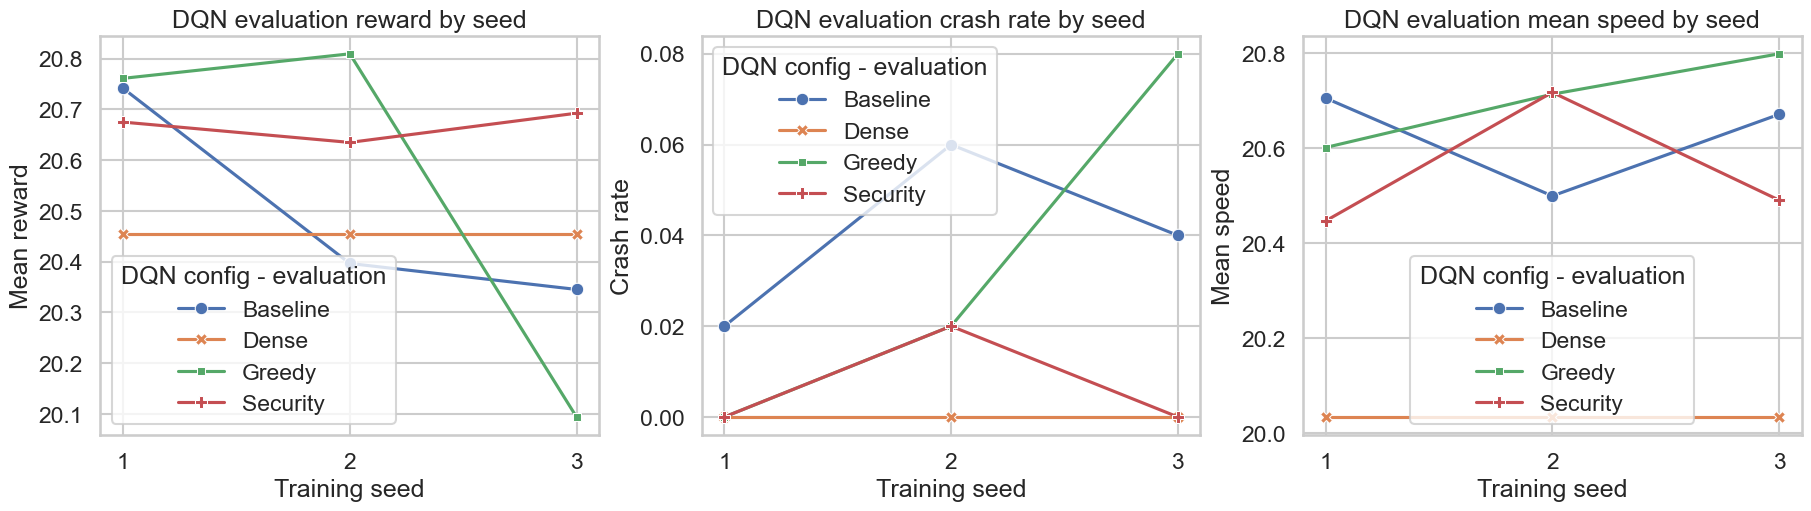

In [43]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

dqn_eval_seed_plot_specs = [
    ("mean_reward", "DQN evaluation reward by seed", "Mean reward"),
    ("crash_rate", "DQN evaluation crash rate by seed", "Crash rate"),
    ("mean_speed", "DQN evaluation mean speed by seed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, dqn_eval_seed_plot_specs):
    sns.lineplot(
        data=dqn_eval_summary_df,
        x="train_seed",
        y=metric,
        hue="config",
        style="config",
        markers=True,
        dashes=False,
        errorbar=None,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Training seed")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(dqn_eval_summary_df["train_seed"].unique()))
    ax.legend(title="DQN config - evaluation")

plt.show()


#### Résumé et graphes agrégés de l’évaluation par configuration

DQN evaluation summary aggregated across seeds.


,config,n_training_seeds,reward_mean,reward_std_across_seeds,mean_internal_std_reward,episode_length_mean,crash_rate_mean,offroad_rate_mean,mean_speed_mean,n_episodes_mean
0,Baseline,3,20.494,0.215,1.574,29.587,0.040,0.0,20.625,50.0
1,Dense,3,20.455,0.000,0.000,30.000,0.000,0.0,20.034,50.0
2,Greedy,3,20.555,0.400,1.316,29.613,0.033,0.0,20.704,50.0
3,Security,3,20.667,0.030,0.724,29.887,0.007,0.0,20.552,50.0


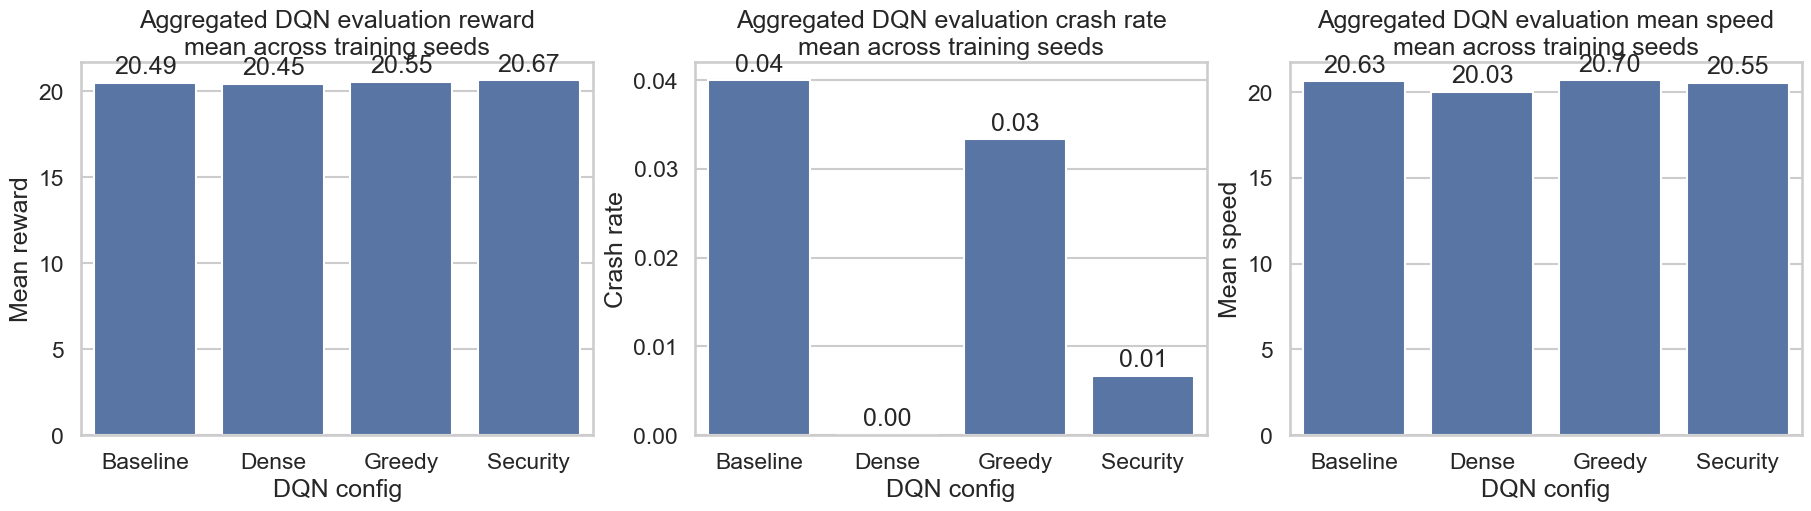

In [ ]:
dqn_eval_config_summary = (
    dqn_eval_summary_df.groupby("config", as_index=False)
    .agg(
        n_training_seeds=("train_seed", "nunique"),
        reward_mean=("mean_reward", "mean"),
        reward_std_across_seeds=("mean_reward", "std"),
        mean_internal_std_reward=("std_reward", "mean"),
        episode_length_mean=("mean_episode_length", "mean"),
        crash_rate_mean=("crash_rate", "mean"),
        offroad_rate_mean=("offroad_rate", "mean"),
        mean_speed_mean=("mean_speed", "mean"),
        n_episodes_mean=("n_episodes", "mean"),
    )
    .sort_values("config")
    .fillna(0.0)
)

print("DQN evaluation summary aggregated across seeds.")
display(dqn_eval_config_summary.round(3))

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

dqn_eval_aggregate_plot_specs = [
    ("reward_mean", "Aggregated DQN evaluation reward", "Mean reward"),
    ("crash_rate_mean", "Aggregated DQN evaluation crash rate", "Crash rate"),
    ("mean_speed_mean", "Aggregated DQN evaluation mean speed", "Mean speed"),
]

for ax, (metric, title, ylabel) in zip(axes, dqn_eval_aggregate_plot_specs):
    sns.barplot(
        data=dqn_eval_config_summary,
        x="config",
        y=metric,
        ax=ax,
    )
    ax.set_title(title + "\nmean across training seeds")
    ax.set_xlabel("DQN config")
    ax.set_ylabel(ylabel)

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()


#### Construction des données épisode par épisode

In [48]:
DQN_EVALUATION_KEY_PATTERN = re.compile(
    r"^evaluation_dqn_(?P<config>[^_]+)_seed_(?P<train_seed>\d+)_.*_df$"
)

dqn_eval_episode_runs = []
for dataframe_name, df in loaded_dataframes.items():
    match = DQN_EVALUATION_KEY_PATTERN.match(dataframe_name)
    if match is None:
        continue

    metadata = match.groupdict()
    run_df = df.copy()
    run_df["model"] = "DQN"
    run_df["config"] = metadata["config"].capitalize()
    run_df["train_seed"] = int(metadata["train_seed"])
    dqn_eval_episode_runs.append(run_df)

if not dqn_eval_episode_runs:
    raise ValueError("No DQN evaluation episode histories found.")

dqn_eval_episode_history = pd.concat(dqn_eval_episode_runs, ignore_index=True)
dqn_eval_episode_history = dqn_eval_episode_history[
    dqn_eval_episode_history["config"].isin(DQN_CONFIGS_TO_COMPARE)
].copy()

dqn_eval_episode_history[["crashed", "offroad"]] = dqn_eval_episode_history[
    ["crashed", "offroad"]
].astype(float)

display(dqn_eval_episode_history.head().round(3))


,episode,seed,reward,length,crashed,offroad,mean_speed,model,config,train_seed
0,0,1,20.796,30,0.0,0.0,20.696,DQN,Baseline,1
1,1,2,20.797,30,0.0,0.0,20.701,DQN,Baseline,1
2,2,3,20.882,30,0.0,0.0,20.839,DQN,Baseline,1
3,3,4,21.143,30,0.0,0.0,21.367,DQN,Baseline,1
4,4,5,21.055,30,0.0,0.0,21.196,DQN,Baseline,1


#### Distribution des rewards d’évaluation par configuration

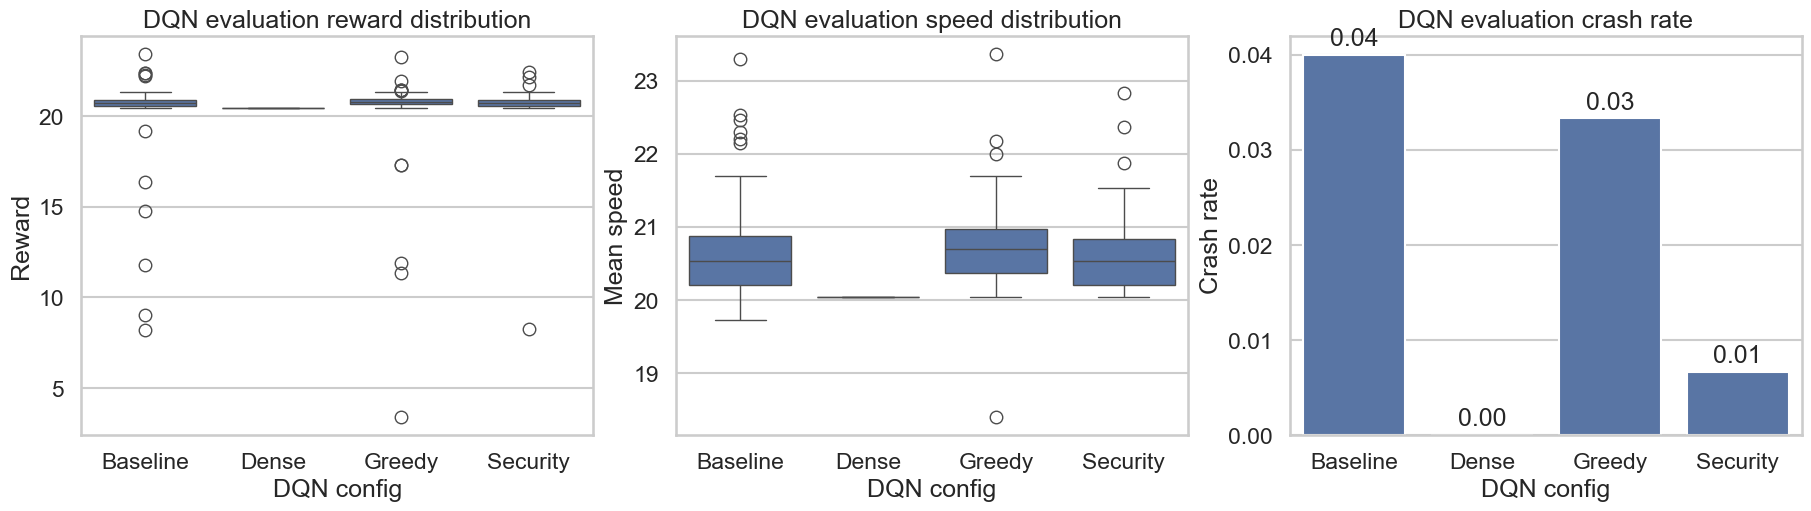

In [49]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
    constrained_layout=True,
)

sns.boxplot(
    data=dqn_eval_episode_history,
    x="config",
    y="reward",
    ax=axes[0],
)
axes[0].set_title("DQN evaluation reward distribution")
axes[0].set_xlabel("DQN config")
axes[0].set_ylabel("Reward")

sns.boxplot(
    data=dqn_eval_episode_history,
    x="config",
    y="mean_speed",
    ax=axes[1],
)
axes[1].set_title("DQN evaluation speed distribution")
axes[1].set_xlabel("DQN config")
axes[1].set_ylabel("Mean speed")

sns.barplot(
    data=dqn_eval_episode_history,
    x="config",
    y="crashed",
    estimator="mean",
    errorbar=None,
    ax=axes[2],
)
axes[2].set_title("DQN evaluation crash rate")
axes[2].set_xlabel("DQN config")
axes[2].set_ylabel("Crash rate")

for container in axes[2].containers:
    axes[2].bar_label(container, fmt="%.2f", padding=3)

plt.show()


#### Etude de la meilleure configuration selon reward et sécurité

In [50]:
dqn_eval_config_ranking = dqn_eval_config_summary.copy()

dqn_eval_config_ranking["reward_rank"] = dqn_eval_config_ranking["reward_mean"].rank(
    ascending=False,
    method="min",
)
dqn_eval_config_ranking["safety_rank"] = dqn_eval_config_ranking["crash_rate_mean"].rank(
    ascending=True,
    method="min",
)
dqn_eval_config_ranking["speed_rank"] = dqn_eval_config_ranking["mean_speed_mean"].rank(
    ascending=False,
    method="min",
)

dqn_eval_config_ranking["overall_rank_score"] = (
    dqn_eval_config_ranking["reward_rank"]
    + dqn_eval_config_ranking["safety_rank"]
    + dqn_eval_config_ranking["speed_rank"]
)

dqn_eval_config_ranking = dqn_eval_config_ranking.sort_values(
    ["overall_rank_score", "reward_rank", "safety_rank"]
)

print("DQN evaluation configuration ranking.")
display(
    dqn_eval_config_ranking[
        [
            "config",
            "reward_mean",
            "crash_rate_mean",
            "mean_speed_mean",
            "reward_rank",
            "safety_rank",
            "speed_rank",
            "overall_rank_score",
        ]
    ].round(3)
)


DQN evaluation configuration ranking.


,config,reward_mean,crash_rate_mean,mean_speed_mean,reward_rank,safety_rank,speed_rank,overall_rank_score
3,Security,20.667,0.007,20.552,1.0,2.0,3.0,6.0
2,Greedy,20.555,0.033,20.704,2.0,3.0,1.0,6.0
0,Baseline,20.494,0.040,20.625,3.0,4.0,2.0,9.0
1,Dense,20.455,0.000,20.034,4.0,1.0,4.0,9.0


## Étude d’un cas d’échec et interprétation
***

### Préparer les données d’évaluation:

In [ ]:
failure_pattern = re.compile(
    r"^evaluation_(?P<model>[^_]+)_(?P<config>[^_]+)_seed_(?P<train_seed>\d+)_.*_df$"
)

MODEL_TYPE_BY_LABEL = {
    "DQN": ModelType.DQN,
    "SB3": ModelType.SB3,
    "2DQN": ModelType.DOUBLE_DQN,
}
FAILURE_MODELS = ["DQN", "SB3", "2DQN"]
FAILURE_METRICS = ["reward", "length", "crashed", "offroad", "mean_speed"]

failure_runs = []
for dataframe_name, df in loaded_dataframes.items():
    match = failure_pattern.match(dataframe_name)
    if match is None:
        continue

    metadata = match.groupdict()
    failure_df = df.copy()
    failure_df["model"] = metadata["model"].upper()
    failure_df["config"] = metadata["config"].capitalize()
    failure_df["train_seed"] = int(metadata["train_seed"])
    failure_runs.append(failure_df)

if not failure_runs:
    raise ValueError("No evaluation dataframe available to identify a failure case.")

failure_history = pd.concat(failure_runs, ignore_index=True)
failure_history[["crashed", "offroad"]] = failure_history[["crashed", "offroad"]].astype(float)

paired_episode_case = failure_history.pivot_table(
    index=["config", "train_seed", "seed", "episode"],
    columns="model",
    values=FAILURE_METRICS,
).reset_index()

paired_episode_case.columns = [
    f"{metric}_{model}" if model else metric for metric, model in paired_episode_case.columns
]

required_model_columns = [
    f"{metric}_{model}" for model in FAILURE_MODELS for metric in FAILURE_METRICS
]
missing_columns = [
    column for column in required_model_columns if column not in paired_episode_case.columns
]
if missing_columns:
    raise ValueError(f"Missing required model columns: {missing_columns}")

paired_episode_case = paired_episode_case.dropna(subset=required_model_columns).copy()

paired_episode_case[[f"failure_intensity_{model.lower()}" for model in FAILURE_MODELS]] = (
    pd.DataFrame(
        {
            f"failure_intensity_{model.lower()}": (
                3 * paired_episode_case[f"crashed_{model}"]
                + 2 * paired_episode_case[f"offroad_{model}"]
                + (30 - paired_episode_case[f"length_{model}"]) / 30
                + (
                    paired_episode_case[f"reward_{model}"].max()
                    - paired_episode_case[f"reward_{model}"]
                )
                / max(
                    1e-9,
                    float(
                        paired_episode_case[[f"reward_{m}" for m in FAILURE_MODELS]].stack().std()
                    ),
                )
            )
            for model in FAILURE_MODELS
        }
    )
)

display(paired_episode_case.head().round(3))


,config,train_seed,seed,episode,crashed_2DQN,crashed_DQN,crashed_SB3,length_2DQN,length_DQN,length_SB3,...,mean_speed_SB3,offroad_2DQN,offroad_DQN,offroad_SB3,reward_2DQN,reward_DQN,reward_SB3,failure_intensity_dqn,failure_intensity_sb3,failure_intensity_2dqn
0,Baseline,1,1,0,0.0,0.0,0.0,30.0,30.0,30.0,...,29.632,0.0,0.0,0.0,20.881,20.796,29.543,0.501,0.078,0.242
1,Baseline,1,2,1,0.0,0.0,0.0,30.0,30.0,30.0,...,29.966,0.0,0.0,0.0,20.969,20.797,29.941,0.501,0.002,0.225
2,Baseline,1,3,2,0.0,0.0,0.0,30.0,30.0,30.0,...,29.966,0.0,0.0,0.0,20.796,20.882,29.938,0.485,0.003,0.258
3,Baseline,1,4,3,0.0,0.0,0.0,30.0,30.0,30.0,...,29.966,0.0,0.0,0.0,21.055,21.143,29.934,0.436,0.003,0.209
4,Baseline,1,5,4,0.0,0.0,0.0,30.0,30.0,30.0,...,29.467,0.0,0.0,0.0,20.970,21.055,29.340,0.452,0.116,0.225


### Sélection automatique d'un cas d’échec

In [ ]:
failure_outcome_columns = [
    *[f"crashed_{model}" for model in FAILURE_MODELS],
    *[f"offroad_{model}" for model in FAILURE_MODELS],
]
intensity_columns = [f"failure_intensity_{model.lower()}" for model in FAILURE_MODELS]

one_sided_failures = paired_episode_case[
    paired_episode_case[failure_outcome_columns].nunique(axis=1) > 1
].copy()

if not one_sided_failures.empty:
    one_sided_failures["decision_score"] = one_sided_failures[intensity_columns].max(axis=1)
    failure_case = one_sided_failures.sort_values("decision_score", ascending=False).iloc[0]
    comparison_label = "one-sided failure"
else:
    shared_failures = paired_episode_case[
        paired_episode_case[failure_outcome_columns].eq(1).any(axis=1)
    ].copy()

    if shared_failures.empty:
        shared_failures = paired_episode_case.copy()

    shared_failures["decision_score"] = shared_failures[intensity_columns].mean(axis=1)
    failure_case = shared_failures.sort_values("decision_score", ascending=False).iloc[0]
    comparison_label = "shared hard case"

focus_model = max(
    FAILURE_MODELS,
    key=lambda model: failure_case[f"failure_intensity_{model.lower()}"],
)

other_model = max(
    [model for model in FAILURE_MODELS if model != focus_model],
    key=lambda model: abs(failure_case[f"reward_{focus_model}"] - failure_case[f"reward_{model}"]),
)

failure_env_type = EnvType[failure_case["config"].upper()]
failure_model_type = MODEL_TYPE_BY_LABEL[focus_model]
failure_train_seed = int(failure_case["train_seed"])
failure_eval_seed = int(failure_case["seed"])

print(
    f"Selected failure case: {comparison_label} | "
    f"config={failure_case['config']} | "
    f"train_seed={failure_train_seed} | "
    f"eval_seed={failure_eval_seed} | "
    f"episode={int(failure_case['episode'])} | "
    f"focus_model={focus_model}"
)


Selected failure case: one-sided failure | config=Baseline | train_seed=3 | eval_seed=51 | episode=48 | focus_model=SB3


### Résumé du cas : 

In [38]:
failure_case_plot = pd.DataFrame(
    [
        {
            "model": model,
            "reward": float(failure_case[f"reward_{model}"]),
            "length": float(failure_case[f"length_{model}"]),
            "crashed": bool(failure_case[f"crashed_{model}"]),
            "offroad": bool(failure_case[f"offroad_{model}"]),
            "mean_speed": float(failure_case[f"mean_speed_{model}"]),
            "failure_intensity": float(failure_case[f"failure_intensity_{model.lower()}"]),
        }
        for model in FAILURE_MODELS
    ]
)

failure_case_plot["status"] = np.select(
    [failure_case_plot["crashed"], failure_case_plot["offroad"]],
    ["Crash", "Offroad"],
    default="Completed",
)

same_case_context = failure_history[
    (failure_history["config"] == failure_case["config"])
    & (failure_history["train_seed"] == int(failure_case["train_seed"]))
    & (failure_history["model"].isin(FAILURE_MODELS))
].copy()

context_by_model = (
    same_case_context.groupby("model", as_index=False)
    .agg(
        reward_mean=("reward", "mean"),
        reward_std=("reward", "std"),
        crash_rate=("crashed", "mean"),
        mean_speed_mean=("mean_speed", "mean"),
        length_mean=("length", "mean"),
    )
    .fillna(0.0)
)

failure_case_plot = failure_case_plot.merge(context_by_model, on="model", how="left")
failure_case_plot["reward_gap_vs_model_mean"] = (
    failure_case_plot["reward"] - failure_case_plot["reward_mean"]
)
failure_case_plot["reward_z_score"] = (
    failure_case_plot["reward_gap_vs_model_mean"]
    / failure_case_plot["reward_std"].replace(0.0, np.nan)
).fillna(0.0)

display(failure_case_plot.round(3))


,model,reward,length,crashed,offroad,mean_speed,failure_intensity,status,reward_mean,reward_std,crash_rate,mean_speed_mean,length_mean,reward_gap_vs_model_mean,reward_z_score
0,DQN,20.540,30.0,False,False,20.201,0.550,Completed,20.345,2.462,0.04,20.671,29.34,0.195,0.079
1,SB3,0.985,2.0,True,False,25.867,9.425,Crash,24.241,8.233,0.42,29.294,24.96,-23.256,-2.825
2,2DQN,20.711,30.0,False,False,20.534,0.274,Completed,20.736,0.279,0.00,20.547,30.00,-0.025,-0.091


### Graphes:

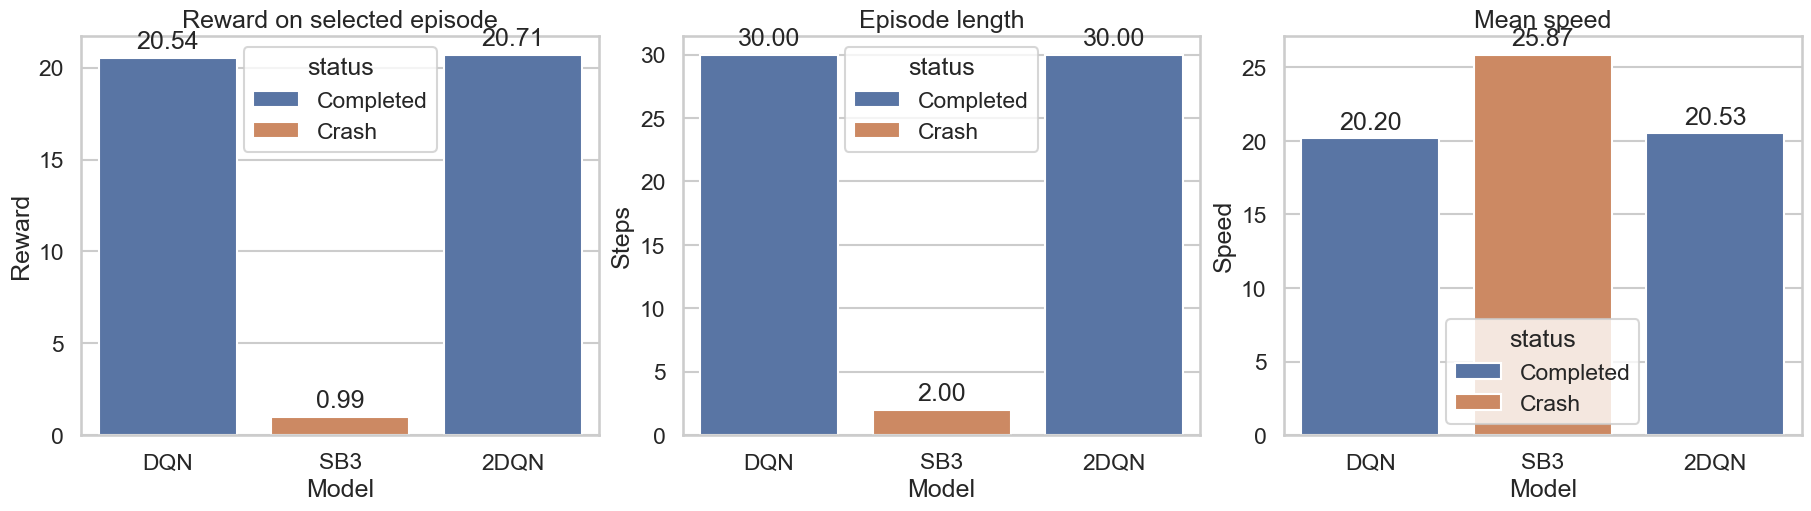

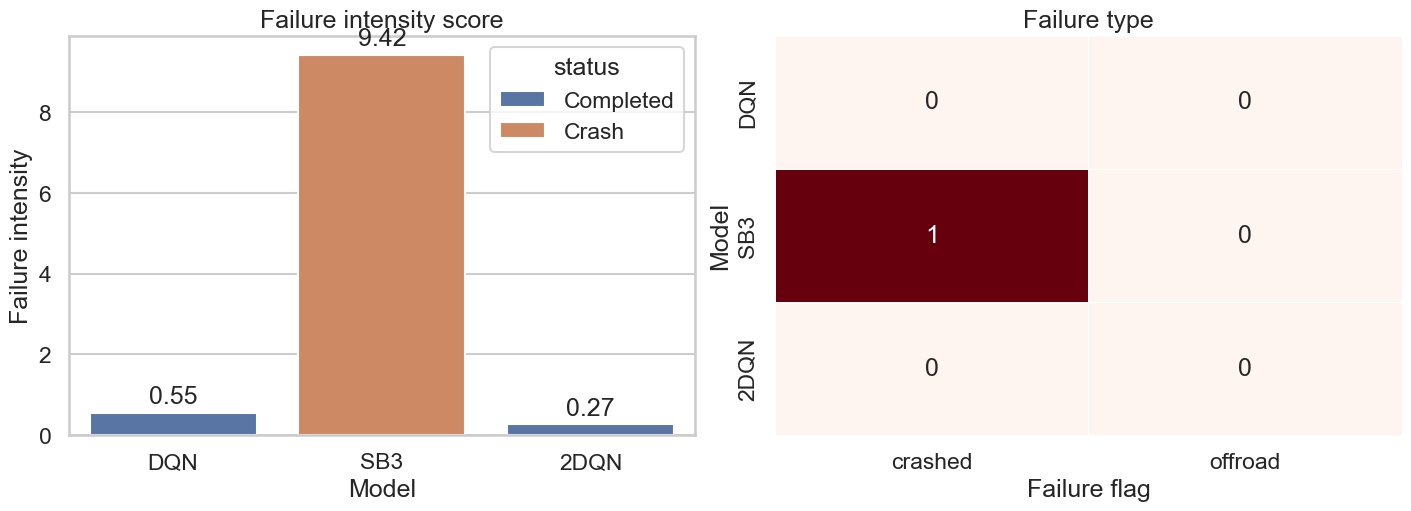

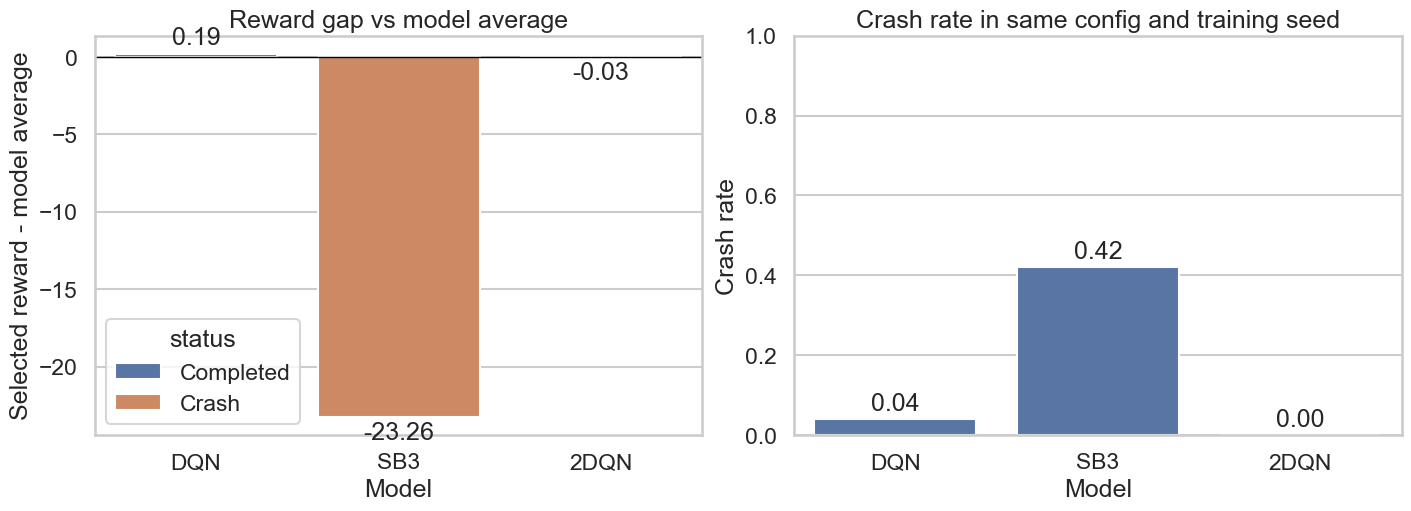

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

for ax, metric, title, ylabel in [
    (axes[0], "reward", "Reward on selected episode", "Reward"),
    (axes[1], "length", "Episode length", "Steps"),
    (axes[2], "mean_speed", "Mean speed", "Speed"),
]:
    sns.barplot(
        data=failure_case_plot,
        x="model",
        y=metric,
        hue="status",
        dodge=False,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3)

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=failure_case_plot,
    x="model",
    y="failure_intensity",
    hue="status",
    dodge=False,
    ax=axes[0],
)
axes[0].set_title("Failure intensity score")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Failure intensity")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

failure_flags = failure_case_plot.set_index("model")[["crashed", "offroad"]].astype(int)
sns.heatmap(
    failure_flags,
    annot=True,
    cmap="Reds",
    cbar=False,
    linewidths=0.5,
    ax=axes[1],
)
axes[1].set_title("Failure type")
axes[1].set_xlabel("Failure flag")
axes[1].set_ylabel("Model")

plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.barplot(
    data=failure_case_plot,
    x="model",
    y="reward_gap_vs_model_mean",
    hue="status",
    dodge=False,
    ax=axes[0],
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Reward gap vs model average")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Selected reward - model average")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f", padding=3)

sns.barplot(
    data=failure_case_plot,
    x="model",
    y="crash_rate",
    ax=axes[1],
)
axes[1].set_title("Crash rate in same config and training seed")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("Crash rate")
axes[1].set_ylim(0, 1)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.2f", padding=3)

plt.show()

### Visualisation : 

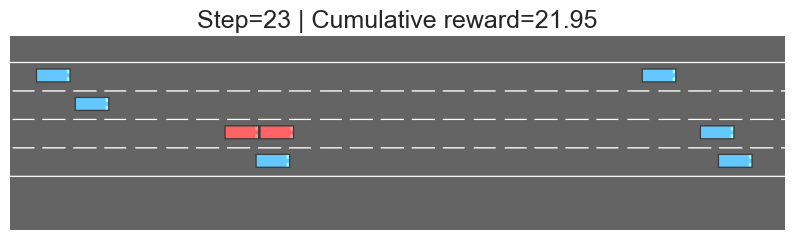

,model,config,train_seed,eval_seed,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,SB3,baseline,3,51,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,21.953471,23,True,False,29.292652


In [35]:
env_id, env_config = get_env_config(failure_env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)

env = benchmark.make_env(seed=failure_eval_seed)
model_path = resolve_model_path(
    project_root=project_root,
    model_type=failure_model_type,
    env_type=failure_env_type,
    train_seed=failure_train_seed,
)

model = load_model(failure_model_type, model_path)

failure_stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)

env.close()

pd.DataFrame(
    [
        {
            "model": focus_model,
            "config": failure_env_type.value,
            "train_seed": failure_train_seed,
            "eval_seed": failure_eval_seed,
            "model_path": str(model_path),
            **failure_stats,
        }
    ]
)


Il se crash parce qu il a pas la place avec al vitesse de redoubler la voiture qui se trouve devant.

## Analyse du comportement du modèle à partir d’un rollout sélectionné
***

pour train_seed = 3 et eval_seed = 34, les trois modèles finissent sans crash, mais SB3 roule beaucoup plus vite :

DQN  reward ≈ 20.455, vitesse ≈ 20.034  

SB3  reward ≈ 29.934, vitesse ≈ 29.966  

2DQN reward ≈ 20.882, vitesse ≈ 20.868  



Viusualisation SB3:

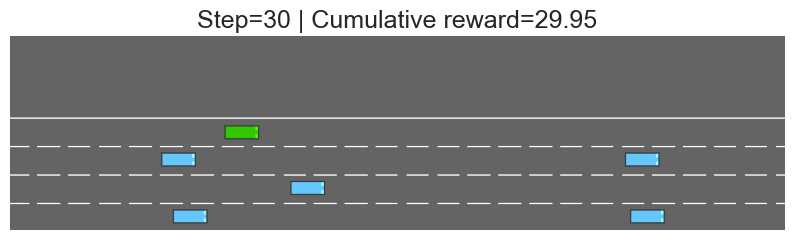

,model,config,train_seed,eval_seed,checkpoint,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,SB3,baseline,3,34,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,29.949761,30,False,False,29.965648


In [31]:
selected_env_type = EnvType.BASELINE
selected_model_type = ModelType.SB3
selected_train_seed = 3
selected_eval_seed = 34
selected_checkpoint = None


def run_selected_rollout(model_type: ModelType, model_label: str) -> dict:
    env_id, env_config = get_env_config(selected_env_type)
    env_config["offscreen_rendering"] = True

    benchmark = HighwayBenchmark(
        config=BenchmarkConfig(
            env_id=env_id,
            env_config=env_config,
        ),
        render_mode="rgb_array",
    )

    env = benchmark.make_env(seed=selected_eval_seed)
    model_path = resolve_model_path(
        project_root=project_root,
        model_type=model_type,
        env_type=selected_env_type,
        train_seed=selected_train_seed,
        checkpoint=selected_checkpoint,
    )
    model = load_model(model_type, model_path)

    rollout_stats = display_episode(
        env=env,
        model=model,
        greedy=True,
        sleep_time=0.03,
    )

    env.close()

    return {
        "model": model_label,
        "config": selected_env_type.value,
        "train_seed": selected_train_seed,
        "eval_seed": selected_eval_seed,
        "checkpoint": selected_checkpoint,
        "model_path": str(model_path),
        **rollout_stats,
    }


sb3_rollout_stats = run_selected_rollout(selected_model_type, "SB3")

pd.DataFrame([sb3_rollout_stats])


Visualisation DQN : 

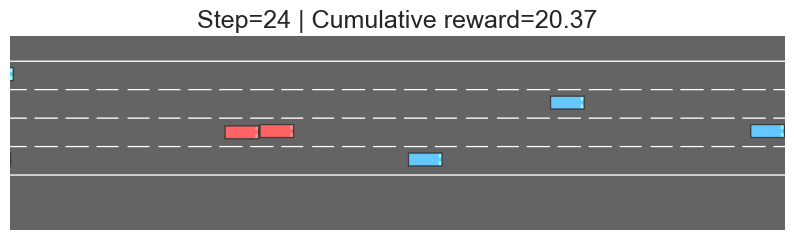

,model,config,train_seed,eval_seed,checkpoint,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,DQN,baseline,3,34,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,20.367585,24,True,False,26.69149


In [32]:
dqn_rollout_stats = run_selected_rollout(ModelType.DQN, "DQN")

pd.DataFrame([dqn_rollout_stats])


Visualisation 2DQN : 


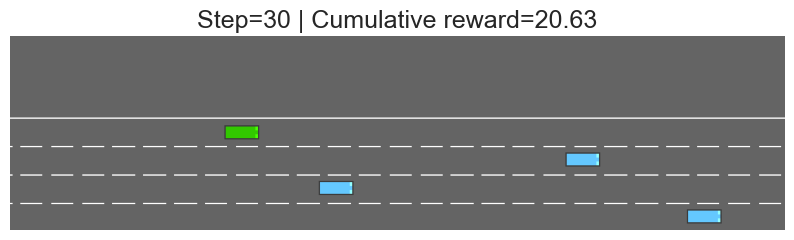

,model,config,train_seed,eval_seed,checkpoint,model_path,episode_reward,episode_length,crashed,offroad,mean_speed
0,2DQN,baseline,3,34,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...,20.626989,30,False,False,20.367685


In [33]:
double_dqn_rollout_stats = run_selected_rollout(ModelType.DOUBLE_DQN, "2DQN")

pd.DataFrame([double_dqn_rollout_stats])


Tableau final : 

In [30]:
rollout_comparison_table = pd.DataFrame(
    [
        sb3_rollout_stats,
        dqn_rollout_stats,
        double_dqn_rollout_stats,
    ]
)

rollout_comparison_table[
    [
        "model",
        "config",
        "train_seed",
        "eval_seed",
        "episode_reward",
        "episode_length",
        "crashed",
        "offroad",
        "mean_speed",
        "checkpoint",
        "model_path",
    ]
].round(3)


,model,config,train_seed,eval_seed,episode_reward,episode_length,crashed,offroad,mean_speed,checkpoint,model_path
0,SB3,baseline,3,34,29.950,30,False,False,29.966,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...
1,DQN,baseline,3,34,20.368,24,True,False,26.691,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...
2,2DQN,baseline,3,34,20.627,30,False,False,20.368,None,c:\Bureau\CS\partie3\RL\RL-project\data\traini...


Pour ce rollout, les trois modèles sont évalués dans les mêmes conditions : configuration baseline, seed d’entraînement 3 et seed d’évaluation 34.

SB3 obtient le meilleur résultat sur cet épisode. Il termine les 30 steps sans crash ni sortie de route, avec un reward de 29.950 et une vitesse moyenne très élevée de 29.966. Visuellement, son comportement est aussi le plus fluide : la voiture garde une trajectoire plus stable et les changements de voie sont moins fréquents. Sur cet épisode, SB3 adopte donc une conduite rapide et efficace, sans provoquer d’accident.

DQN a un comportement moins bon sur ce même rollout. Il obtient un reward de 20.368, mais l’épisode s’arrête après 24 steps à cause d’un crash. Sa vitesse moyenne est pourtant assez élevée (26.691), ce qui suggère que le modèle prend plus de risques sans réussir à maintenir une conduite sûre jusqu’à la fin même si il change peu de file. Le seul changement a conduit au crash. Dans ce cas précis, DQN ne parvient pas à gérer correctement la situation de trafic.

2DQN termine l’épisode complet sans crash ni sortie de route, avec un reward de 20.627 et une vitesse moyenne de 20.368. Il est donc plus sûr que DQN sur ce rollout. En revanche, son comportement est beaucoup fluide que celui de SB3 : la voiture effectue beaucoup de changements de file non nécessaire, ce qui donne une conduite très instable. Même si 2DQN évite l’accident, il reste plus prudent et moins performant que SB3 sur cet épisode.

Ce rollout illustre bien les différences entre les modèles. SB3 est le plus performant ici, car il combine vitesse élevée, trajectoire fluide et absence de crash. DQN est plus risqué et finit par crasher. 2DQN est plus sûr que DQN, mais sa conduite est moins fluide et son reward reste proche de celui de DQN, loin derrière SB3.

## A FAIRE a short discussion of design choices
***